# 客户流失大数据挖掘
## 一、数据预览与质量评估

### （一） **数据预览**
- 导入数据集，初步查看数据前五行，以了解数据内容。
- 查看数据整体信息摘要和基础统计信息查看。明确整体数据结构。
### （二） **数据质量评估**

1. **缺失值检测与处理**：从数据的整体信息摘要中，可以看出不存在缺失值，也就不需要进行处理。
2. **重复值检测与处理**：检测是否存在重复值行，如果存在，删除重复行。
3. **异常值检测与处理**：
- 对数值型变量，绘制直方图，显示数值变量的分布情况，绘制箱线图可视化图表，查看存在异常值，计算四分位数创建二维数组显示并储存异常值。
- 对于分类变量，将数值化的分类变量转换成字符类型与已经存在的字符列合并，生成完整分类变量列表，绘制各类别的频次分布图，识别出不符合逻辑或极少数出现的类别，判断是否为异常值。
- 根据异常值的性质和业务背景，决定是删除异常值、修正异常值还是保留异常值并进行特殊处理。

## 二、数据处理

### （一）将数据筛选
**基于条件筛选数据**：先深复制原表，删除无关实验变量，筛选出分类变量与数值变量的新表。
### （二）数值变量离散化
1. **自定义分箱**：根据业务经验和对数据的理解，对数值列自定义分箱。在分箱过程中，需要确保每个数据点都能准确地映射到相应的类别中，避免出现数据丢失或分类错误的情况。
2. 聚类分箱：Mean Shift 密度聚类：网格搜索参数优化
- **聚类分箱应用**：使用优化后的 Mean Shift 密度聚类算法对数据进行聚类分箱，将数据划分为若干个聚类簇。将聚类结果作为新的类别变量，为后续的分析和建模提供更丰富的特征信息。
- **参数优化：网格搜索**：使用分位数法预计算带宽范围，动态调整网格参数空间。对于每个带宽参数值，运行 Mean Shift 密度聚类算法，计算聚类结果的轮廓系数, Calinski-Harabasz指数构建评价指标函数，找到最优带宽参数。
### （三）变量热编码
1. **对 df 进行全热编码**： 对每个分类变量的每个类别创建一个新的二进制变量。便于后续的数学计算和模型训练。同时设置自动删除每个分类变量的第一列，避免陷入虚拟变量陷阱。
2. **对 df1 分类变量进行哑变量操作；连续数值进行最大最小正则化**：
- **哑变量操作**：对 df1 数据集中的分类变量进行哑变量处理，类似于热编码的过程，为每个类别创建一个新的二进制变量，将分类变量转换为数值型变量。
- **最大最小正则化**：对 df1 数据集中的连续数值变量进行最大最小正则化处理。通过$sklearn$库计算每个数值变量的最大值和最小值，然后将每个数据点的值转换为在 [0, 1] 区间内的标准化值，公式为：    
$$
z_i = \frac{x_i - \min(X)}{\max(X) - \min(X)}
$$
其中：$x_i$ 表示原始数据集中的第 $i$ 个观测值$\min(X)$ 和 $\max(X)$ 分别表示数据集 $X$ 的最小值和最大值$z_i$ 表示标准化后的结果，通常位于区间 $[0, 1]$

3. **对 df3 只进行数值标准化**
- 对 df3 数据集中的数值变量使用Z - score方法进行标准化处理，使数据具有统一的尺度。其公式为Z-score（也称为标准分数）是一种标准化方法，用于衡量原始数据点相对于其分布的位置。其公式如下：
$$
z_i = \frac{x_i - \mu}{\sigma}
$$
其中：$x_i$ 是原始数据点$\mu$ 是数据集的均值（期望值）$\sigma$ 是数据集的标准差$z_i$ 表示 $x_i$ 距离均值 $\mu$ 的标准差倍数
## 三、灰色关联分析

### （一）APRIOT 与 FP - Growth
1. 转换为事务列表
2. 使用TransactionEncoder进行编码
3. 自定义支持度和置信度，利用 Apriori 与FP - Growth算法找出频繁项集；支持度为0.05，限制项集长度为3为 Apriori与FP - Growth 频繁项集生成关联规则：置信度为0.8
4. 评估指标：添加 lift（提升度）筛选，避免虚假关联
5. 筛选出包含客户流失的规则

### （二）FP - Growth 参数优化：随机搜索
1. **参数选择与范围设定**：确定 FP - Growth 算法的优化参数：最小支持度阈值（`min_support`）从 0.02 到 0.2，几何序列生成 8 个候选值；最小置信度阈值（`min_threshold`）从 0.4 到 0.7，线性序列生成 5 个候选值。
2. **随机搜索实施**：利用 `ParameterSampler` 进行 10 次随机采样，生成参数组合。对每组参数：使用 `fpgrowth` 挖掘频繁项集。若频繁项集为空，跳过当前组合。使用 `association_rules` 生成关联规则。调用 `evaluate_rules` 评估规则质量，保留与“用户流失标签_1”相关且提升度大于 1 的规则，结合多种指标计算质量得分。
3. **优化结果分析与选择**：记录各参数组合的得分，选择得分最高的组合为最优参数。使用最优参数重新运行 FP - Growth，得到最终的频繁项集和关联规则，为业务决策提供依据。
4. **最终规则筛选与展示**：从最终规则中筛选与“用户流失标签_1”相关且提升度大于 1 的规则，按提升度降序排列，展示关键字段，直观呈现与客户流失相关的规则及其重要性。

## 四、聚类分析
### （一）K - Means 聚类分析
1. **聚类过程**：设定聚类簇个数 \(K\)，确定初始簇中心。将数据点分配到最近的簇中心，重新计算簇中心，重复此过程直至算法收敛。
2. **结果评估与选择**：使用轮廓系数、Davies - Bouldin 指数等评价指标评估不同 \(K\) 值下的聚类结果，选择最优簇个数。通过肘部法确定最佳 \(K\) 值，并可视化聚类结果，分析解读聚类结果为业务决策提供支持。
### （二）K - Prototypes 聚类分析
1. **参数设置与聚类实施**：设定聚类簇个数 \(K\)，选择初始化方法确定初始簇中心。运行 K - Prototypes 算法，根据距离计算方法更新簇中心和数据点归属，直至收敛。
2. **结果评估与应用**：使用适合混合数据类型的评价指标评估聚类结果，调整参数获得更优结果。分析每个簇的特征和业务含义，将聚类结果应用于实际业务场景，如客户细分等。




# 一、数据预览与质量评估

In [22]:
 
# 基础库导入
 
import pandas as pd
import numpy as np
import os
import time
from copy import deepcopy

 
# 可视化库导入
 
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from IPython.display import display, HTML

 
# 机器学习库导入
 
from sklearn.cluster import MeanShift, OPTICS, estimate_bandwidth, KMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.model_selection import ParameterGrid, ParameterSampler
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

 
# 关联规则挖掘库导入
 
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

 
# 混合数据聚类库导入
 
from kmodes.kprototypes import KPrototypes


# 全局配置

# seaborn 样式配置
sns.set_theme(style="whitegrid", palette="viridis")
sns.set_context("paper", font_scale=1.2)

# matplotlib 中文字体配置，seaborn会重置plt设置
try:
    # 尝试使用中文字体
    plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei', 'SimHei', 'DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
    plt.rcParams['figure.dpi'] = 150           # 设置图像清晰度
    plt.rcParams['savefig.dpi'] = 300
except:
    print("警告：中文字体配置失败，可能无法正确显示中文")

# 路径配置
BASE_DIR = "/home/wg/文档/Learning/Project/customer_churn_analysis"
os.chdir(BASE_DIR)
DATA_DIR = os.path.join(BASE_DIR, "data")

# 文件路径
PATH_CUSTOMER_DATA = os.path.join(DATA_DIR, "customer_churn_data.xlsx")
PATH_SALES_DATA = os.path.join(DATA_DIR, "sales.csv")

# 随机种子（确保可重复性）
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

 
# 工具函数
 
def q(df_slice, justify="center"):
    """
    智能显示控制 - 美化DataFrame输出
    
    参数:
        df_slice: 要显示的DataFrame
        justify: 对齐方式 ('left', 'center', 'right')
    
    用法:
        q(df.head(10))  # 显示前10行，居中对齐
    """
    display(HTML(df_slice.to_html(justify=justify)))


print("客户流失分析项目")
print(f"工作目录: {BASE_DIR}")
print(f"数据目录: {DATA_DIR}")
print(f"随机种子: {RANDOM_STATE}")


客户流失分析项目
工作目录: /home/wg/文档/Learning/Project/customer_churn_analysis
数据目录: /home/wg/文档/Learning/Project/customer_churn_analysis/data
随机种子: 42


## （一）数据预览


In [23]:
 
# Section 1: 数据预览与质量评估
 

 
# 1.1 数据加载
 
print("正在加载数据...")

# 读取客户流失数据
raw_df = pd.read_excel(PATH_CUSTOMER_DATA)
print(f"✓ 客户流失数据加载完成: {raw_df.shape[0]} 行, {raw_df.shape[1]} 列")

# 读取销售数据（如有需要）
# sales_df = pd.read_csv(PATH_SALES_DATA, sep=';')
# print(f"✓ 销售数据加载完成: {sales_df.shape[0]} 行, {sales_df.shape[1]} 列")

print(f"\n数据加载完成！")

正在加载数据...
✓ 客户流失数据加载完成: 901 行, 19 列

数据加载完成！


In [24]:
 
# 1.2 数据预览
 
print("数据前5行预览:")
q(raw_df.head())

print("\n数据基础信息:")
raw_df.info()

print("\n数据统计摘要:")
q(raw_df.describe().round(2))

 
# 数据集说明
 
print("\n" + "=" * 80)
print("数据集说明")
print("=" * 80)
print(f"样本数量: {raw_df.shape[0]}")
print(f"特征数量: {raw_df.shape[1]}")
print(f"流失率: {raw_df['用户流失标签'].mean():.2%}")

数据前5行预览:


,顾客ID,用户流失标签,使用平台时间_月,常用登陆设备,城市等级,仓库到顾客地址,婚姻情况,年龄分组,性别,使用App时间_时,上月订单数量单,订单数量较去年增加_单,距上次下单天数_天,上月客户的首选订单类别,用户关注的主播数量,顾客对服务的满意度,上月投诉次数,上月使用的优惠劵数量_张,上月平均折扣金额
0,50001,1,4,Mobile Phone,3,6,Single,3,Female,3,1,11,5,Laptop & Accessory,9,2,1,1,159.93
1,50002,1,4,Phone,1,8,Single,4,Male,3,1,15,0,Household,7,3,1,0,120.90
2,50003,1,4,Phone,1,30,Single,4,Male,2,1,14,3,Household,6,3,1,0,120.28
3,50004,1,3,Phone,3,15,Single,4,Male,2,1,23,3,Laptop & Accessory,8,5,0,0,134.07
4,50005,1,3,Phone,1,12,Single,3,Male,3,1,11,3,Household,3,5,0,1,129.60



数据基础信息:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 901 entries, 0 to 900
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   顾客ID          901 non-null    int64  
 1   用户流失标签        901 non-null    int64  
 2   使用平台时间_月      901 non-null    int64  
 3   常用登陆设备        901 non-null    object 
 4   城市等级          901 non-null    int64  
 5   仓库到顾客地址       901 non-null    int64  
 6   婚姻情况          901 non-null    object 
 7   年龄分组          901 non-null    int64  
 8   性别            901 non-null    object 
 9   使用App时间_时     901 non-null    int64  
 10  上月订单数量单       901 non-null    int64  
 11  订单数量较去年增加_单   901 non-null    int64  
 12  距上次下单天数_天     901 non-null    int64  
 13  上月客户的首选订单类别   901 non-null    object 
 14  用户关注的主播数量     901 non-null    int64  
 15  顾客对服务的满意度     901 non-null    int64  
 16  上月投诉次数        901 non-null    int64  
 17  上月使用的优惠劵数量_张  901 non-null    int64  
 18  上月平均折扣金额      901 non

,顾客ID,用户流失标签,使用平台时间_月,城市等级,仓库到顾客地址,年龄分组,使用App时间_时,上月订单数量单,订单数量较去年增加_单,距上次下单天数_天,用户关注的主播数量,顾客对服务的满意度,上月投诉次数,上月使用的优惠劵数量_张,上月平均折扣金额
count,901.00,901.00,901.00,901.00,901.00,901.00,901.00,901.00,901.00,901.00,901.00,901.00,901.00,901.00,901.00
mean,50451.00,0.19,10.10,1.65,15.35,3.22,2.45,2.56,15.15,4.40,3.76,3.25,0.30,1.24,166.41
std,260.24,0.39,8.13,0.92,8.05,0.83,0.53,2.89,3.56,4.02,2.65,1.10,0.46,1.80,49.19
min,50001.00,0.00,1.00,1.00,5.00,1.00,0.00,1.00,11.00,0.00,1.00,2.00,0.00,0.00,0.00
25%,50226.00,0.00,3.00,1.00,8.00,3.00,2.00,1.00,12.00,2.00,2.00,2.00,0.00,0.00,128.75
50%,50451.00,0.00,7.00,1.00,14.00,3.00,2.00,1.00,14.00,3.00,3.00,3.00,0.00,1.00,148.83
75%,50676.00,0.00,15.00,3.00,20.00,4.00,3.00,3.00,18.00,7.00,5.00,4.00,1.00,1.00,187.22
max,50901.00,1.00,33.00,3.00,35.00,5.00,3.00,15.00,25.00,17.00,21.00,5.00,1.00,15.00,299.99



数据集说明
样本数量: 901
特征数量: 19
流失率: 19.09%


In [25]:
 
# 1.3 数据质量评估
 
print("【缺失值检测】")
missing_values = raw_df.isnull().sum()
if missing_values.sum() == 0:
    print("✓ 数据中不存在缺失值")
else:
    print("发现缺失值:")
    q(missing_values[missing_values > 0].to_frame("缺失数量"))

print("\n【重复值检测】")
duplicates_count = raw_df.duplicated().sum()
if duplicates_count == 0:
    print("✓ 数据中不存在重复值")
else:
    print(f"发现 {duplicates_count} 行重复值，已删除")
    raw_df.drop_duplicates(inplace=True)

print("\n【数据类型检查】")
print(raw_df.dtypes)

【缺失值检测】
✓ 数据中不存在缺失值

【重复值检测】
✓ 数据中不存在重复值

【数据类型检查】
顾客ID              int64
用户流失标签            int64
使用平台时间_月          int64
常用登陆设备           object
城市等级              int64
仓库到顾客地址           int64
婚姻情况             object
年龄分组              int64
性别               object
使用App时间_时         int64
上月订单数量单           int64
订单数量较去年增加_单       int64
距上次下单天数_天         int64
上月客户的首选订单类别      object
用户关注的主播数量         int64
顾客对服务的满意度         int64
上月投诉次数            int64
上月使用的优惠劵数量_张      int64
上月平均折扣金额        float64
dtype: object


##  （二）数据质量评估
- **缺失值检测与处理**

 **重复值检测与处理**： 检测是否存在重复值行，如果存在，删除重复行。

- **异常值检测与处理**

- 数值数据

【数值变量分布】


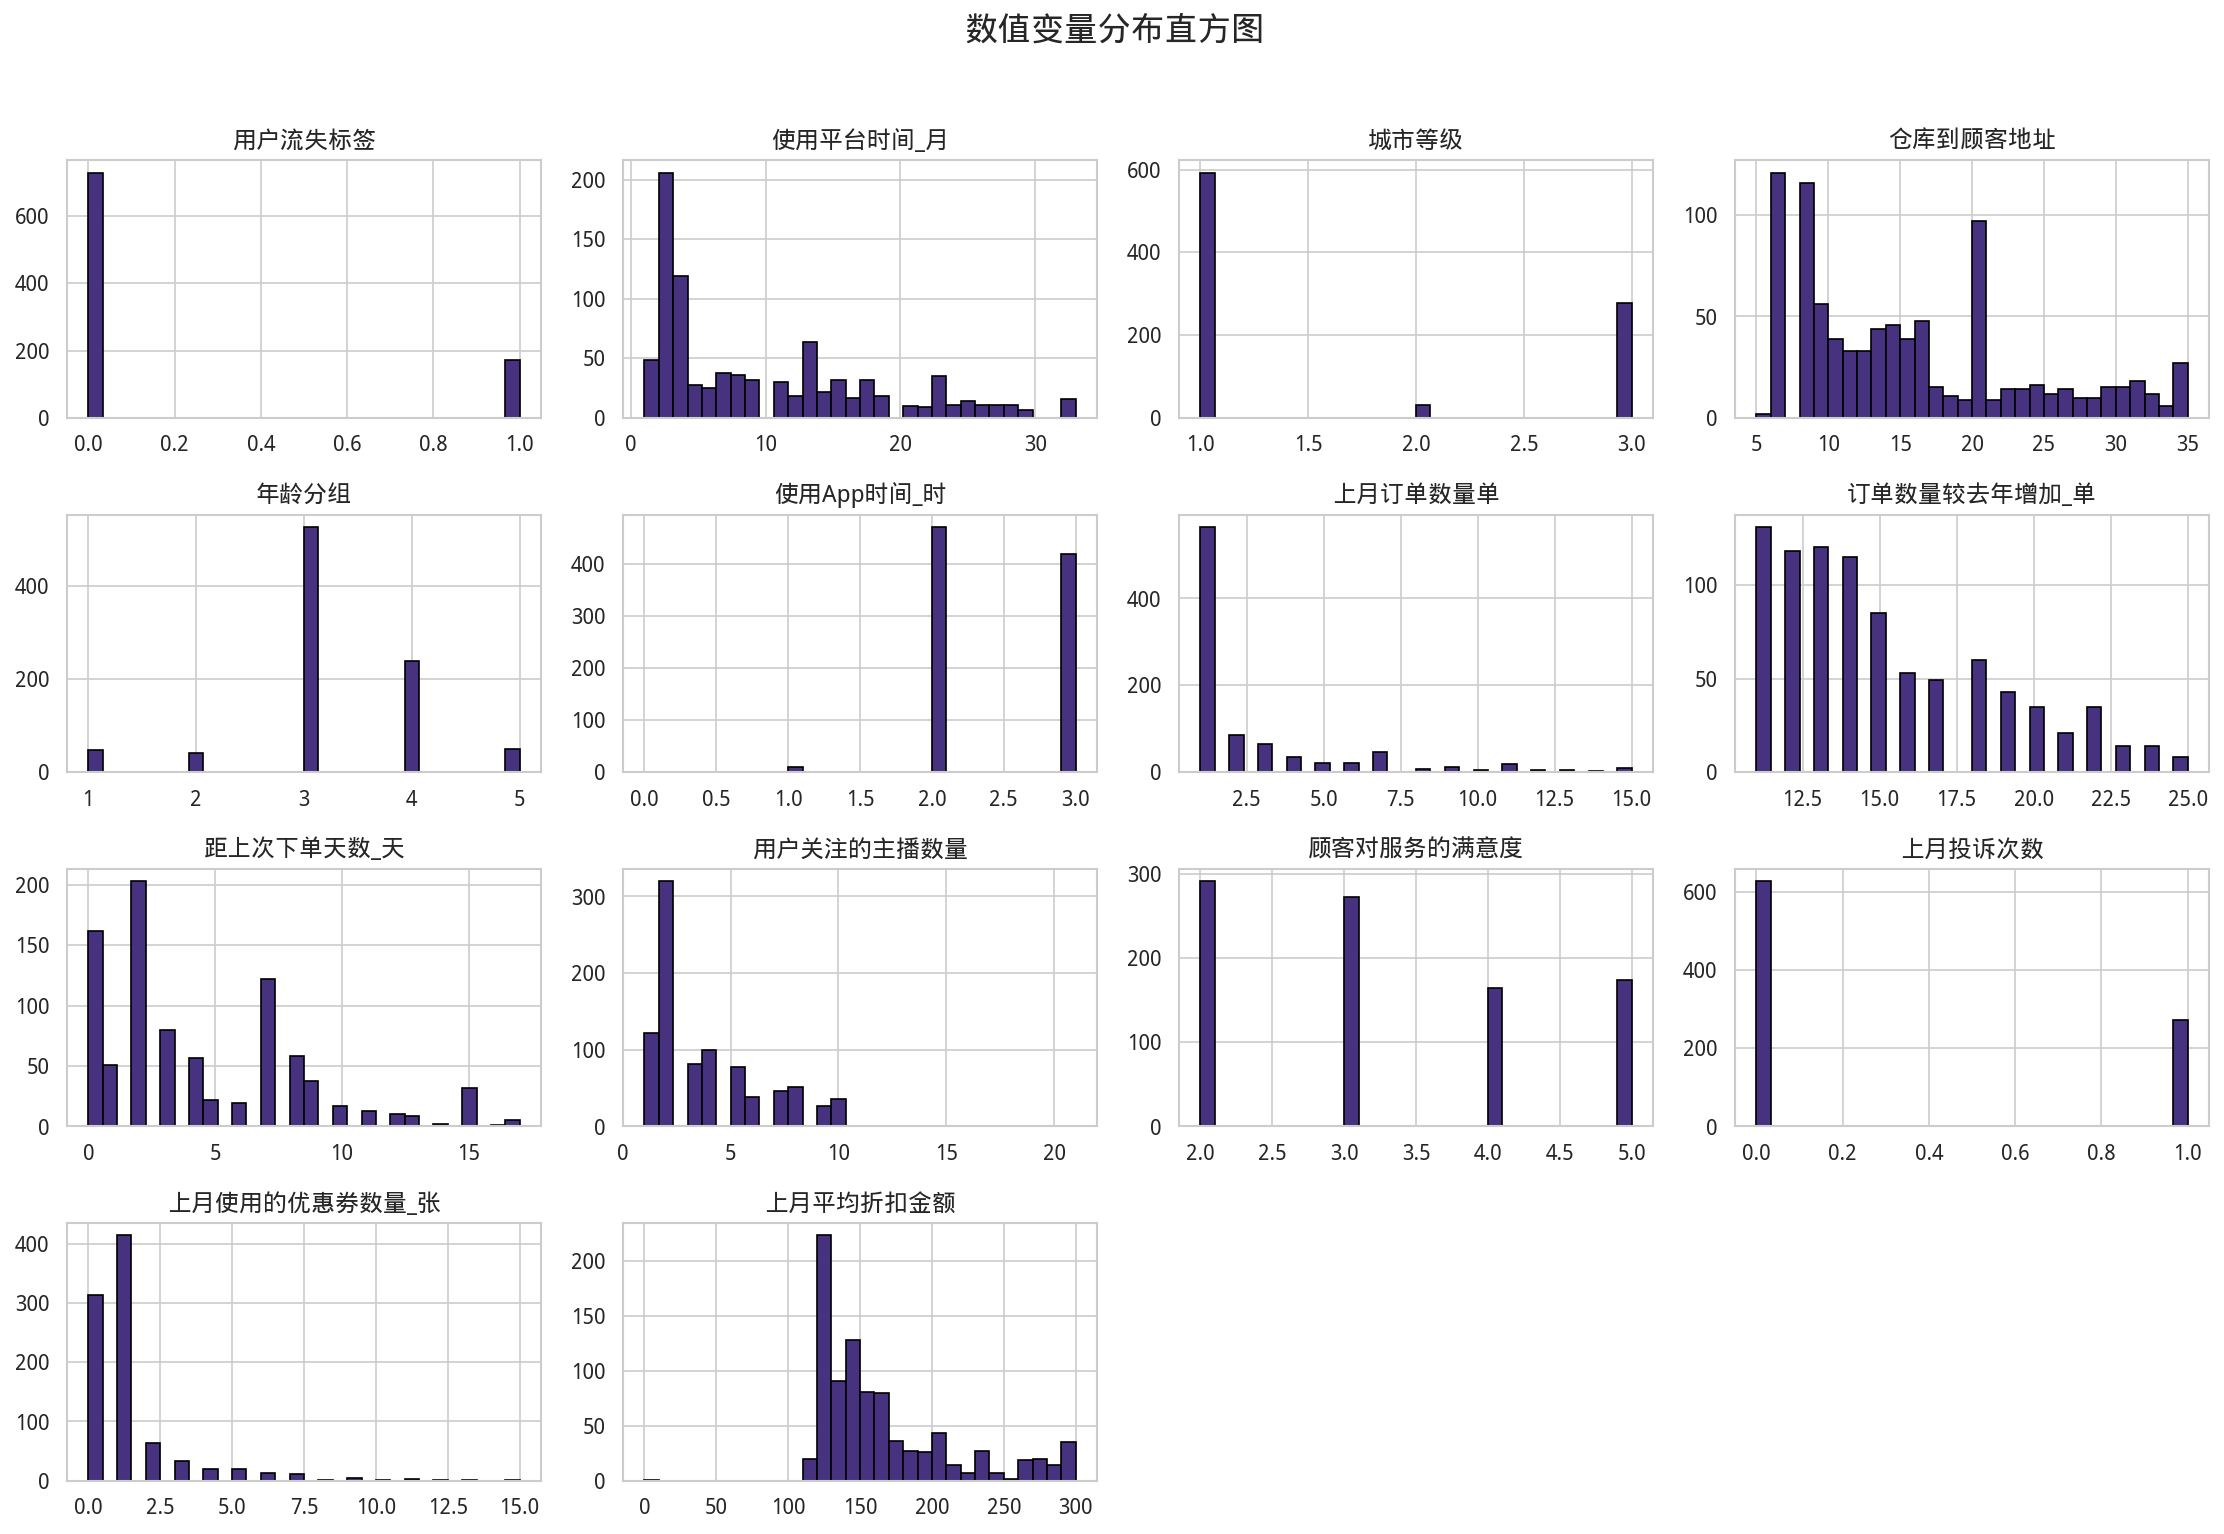


【数值变量箱线图 - 异常值检测】


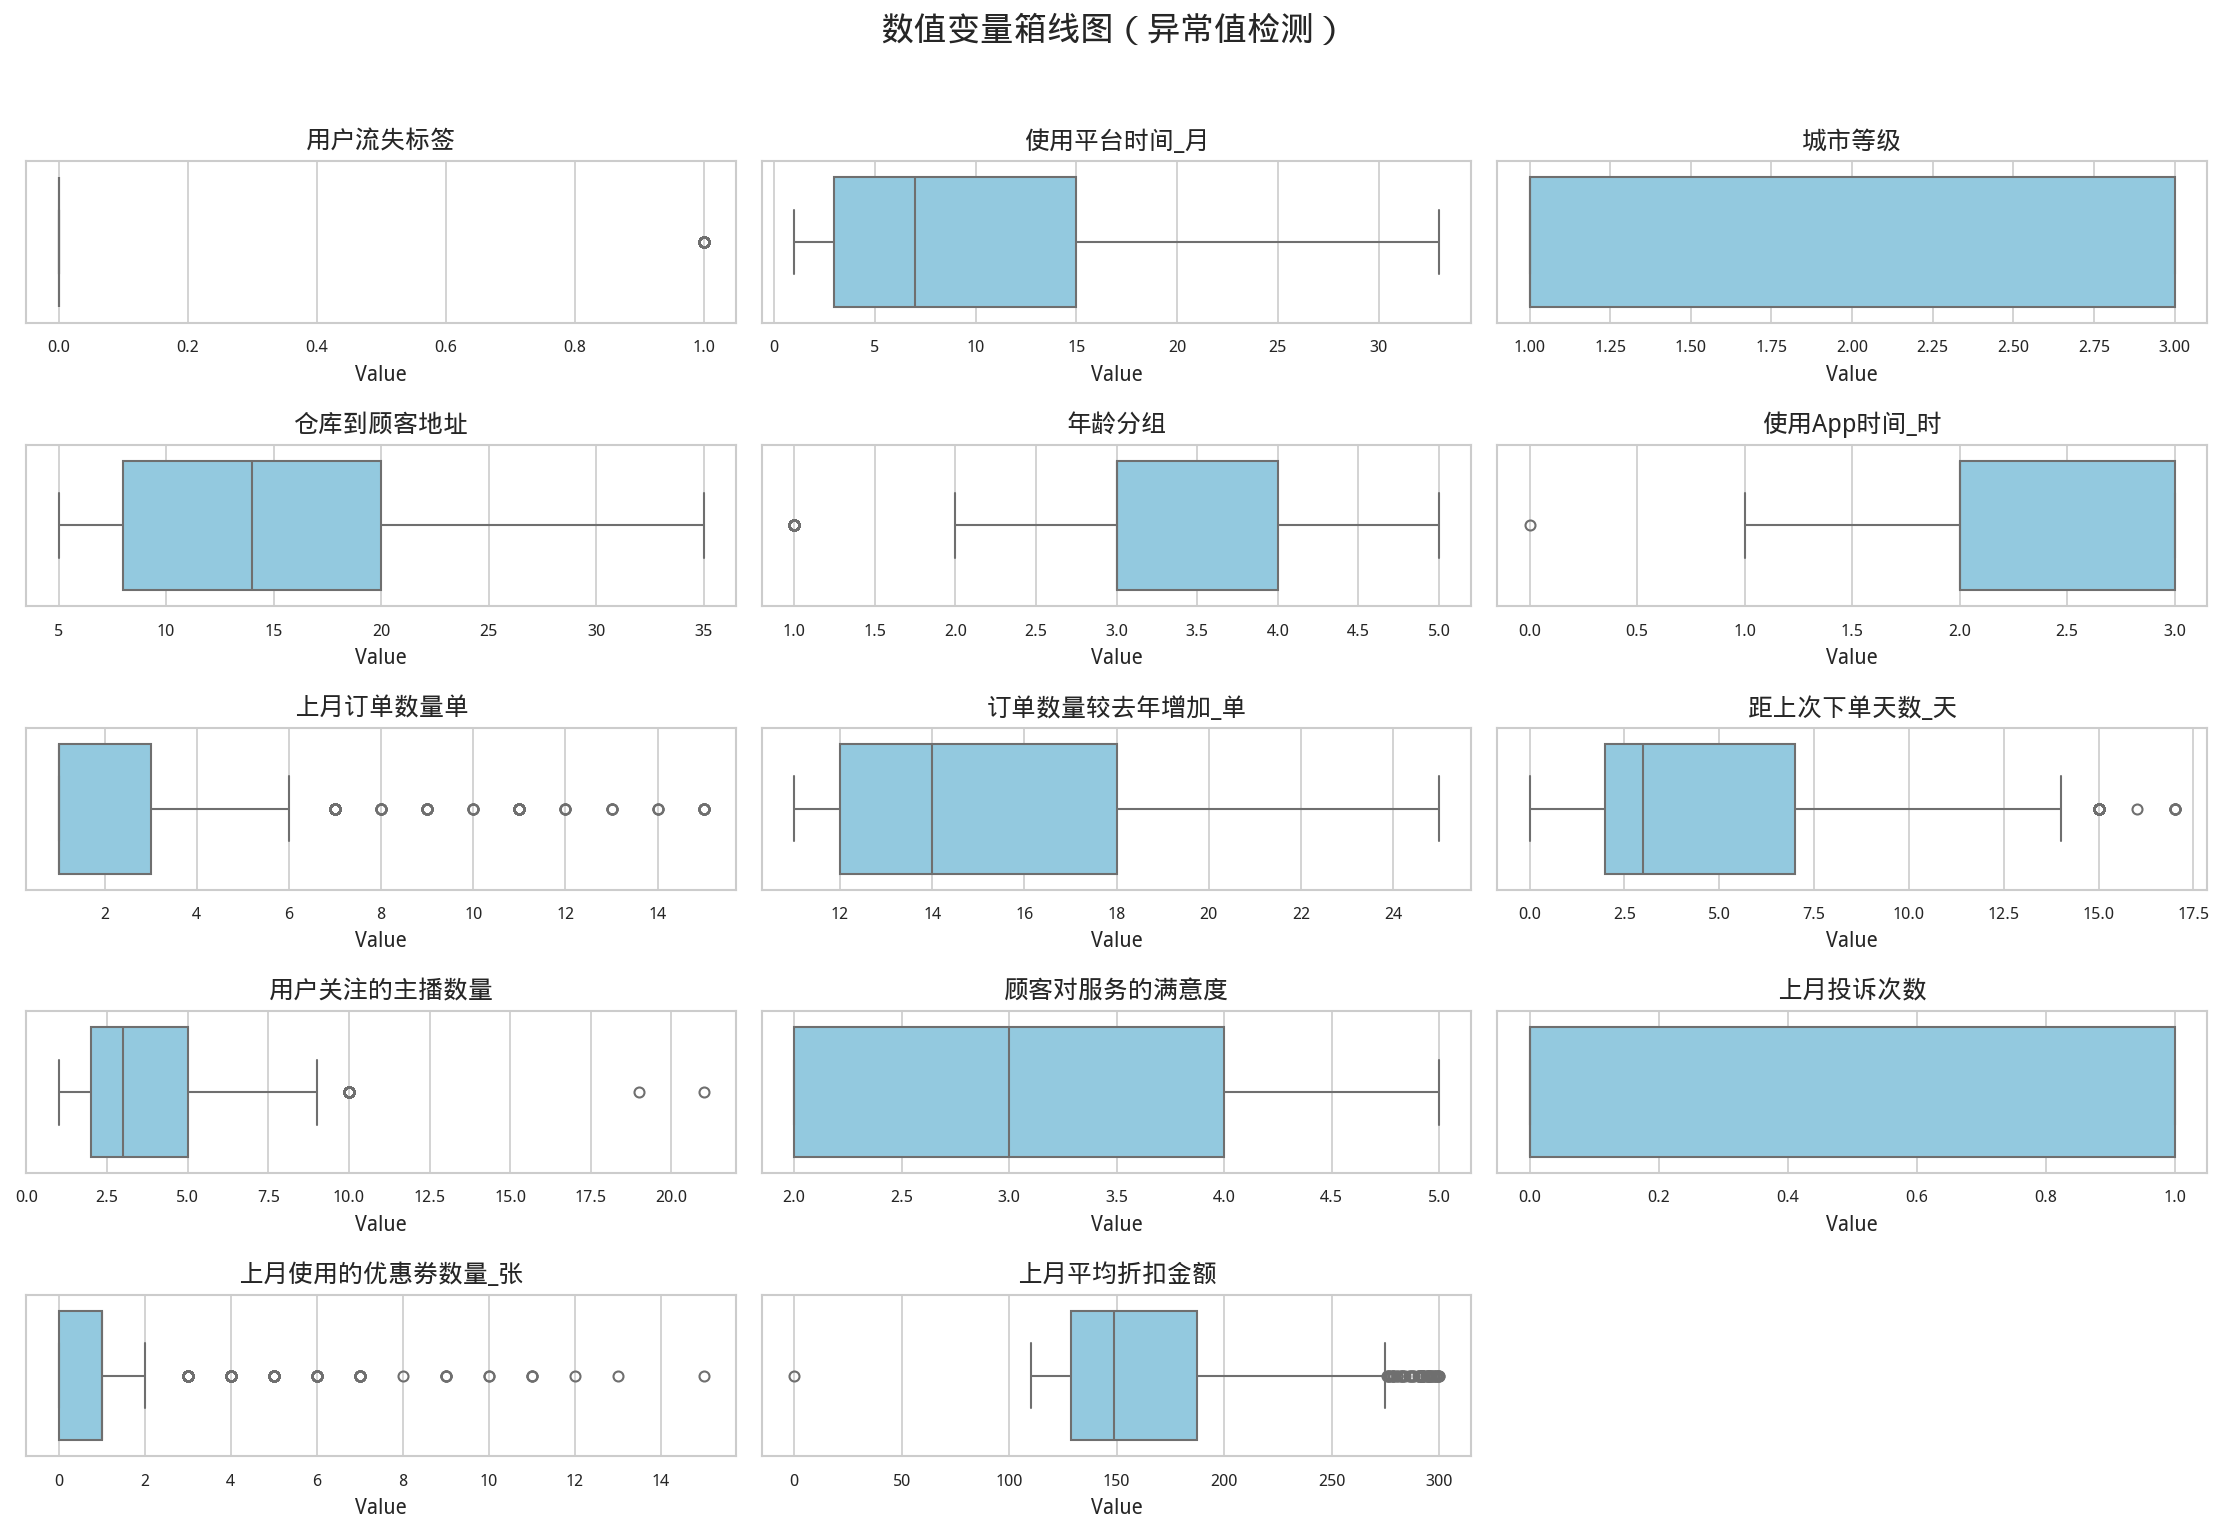


【异常值检测报告】
发现 8 个特征存在异常值：


,Column,Anomaly_Count,Anomaly_Percentage,Lower_Bound,Upper_Bound
0,用户流失标签,172,19.09%,0.000,0.000
1,年龄分组,47,5.22%,1.500,5.500
2,使用App时间_时,1,0.11%,0.500,4.500
3,上月订单数量单,107,11.88%,-2.000,6.000
4,距上次下单天数_天,38,4.22%,-5.500,14.500
5,用户关注的主播数量,38,4.22%,-2.500,9.500
6,上月使用的优惠劵数量_张,111,12.32%,-1.500,2.500
7,上月平均折扣金额,59,6.55%,41.045,274.925



总计异常值数量: 573


In [26]:
 
# 可视化工具函数定义
 

def plot_histograms(df, cols, title="数值变量分布", figsize=(15, 10)):
    """
    绘制数值变量的直方图
    
    参数:
        df: 数据框
        cols: 要绘制的列名列表
        title: 图表标题
        figsize: 图表大小
    """
    df[cols].hist(figsize=figsize, bins=30, xlabelsize=10, ylabelsize=10, edgecolor='black')
    plt.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

def plot_boxplots(df, cols, title="数值变量箱线图", figsize=(15, 10)):
    """
    绘制数值变量的箱线图（用于异常值检测）
    
    参数:
        df: 数据框
        cols: 要绘制的列名列表
        title: 图表标题
        figsize: 图表大小
    """
    num_plots = len(cols)
    num_columns = 3
    num_rows = (num_plots + num_columns - 1) // num_columns
    
    fig, axes = plt.subplots(num_rows, num_columns, figsize=figsize)
    axes = axes.flatten()
    
    for i, col in enumerate(cols):
        sns.boxplot(x=df[col], ax=axes[i], color='skyblue')
        axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel('Value', fontsize=10)
        axes[i].tick_params(axis='both', which='major', labelsize=8)
    
    # 关闭多余的子图
    if num_plots < num_rows * num_columns:
        for j in range(num_plots, num_rows * num_columns):
            axes[j].axis('off')
    
    plt.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

def plot_countplots(df, cols, title="分类变量频次分布", figsize=(15, 10)):
    """
    绘制分类变量的计数图
    
    参数:
        df: 数据框
        cols: 要绘制的列名列表
        title: 图表标题
        figsize: 图表大小
    """
    num_plots = len(cols)
    num_columns = 3
    num_rows = (num_plots + num_columns - 1) // num_columns
    
    fig, axes = plt.subplots(num_rows, num_columns, figsize=figsize)
    axes = axes.flatten()
    
    for i, col in enumerate(cols):
        sns.countplot(x=col, data=df, ax=axes[i], hue=col, palette='viridis', legend=False)
        axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel(col, fontsize=10)
        axes[i].set_ylabel('频次', fontsize=10)
        axes[i].tick_params(axis='both', which='major', labelsize=8)
    
    # 关闭多余的子图
    if num_plots < num_rows * num_columns:
        for j in range(num_plots, num_rows * num_columns):
            axes[j].axis('off')
    
    plt.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

 
# 异常值检测函数
 

def detect_outliers_iqr(df, cols):
    """
    使用IQR方法检测异常值
    
    参数:
        df: 数据框
        cols: 要检测的数值列列表
    
    返回:
        anomalies_df: 包含异常值信息的数据框
    """
    anomalies_list = []
    
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        # 定义异常值范围
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # 标记异常值
        is_outlier = (df[col] < lower_bound) | (df[col] > upper_bound)
        outlier_count = is_outlier.sum()
        
        if outlier_count > 0:
            anomalies_list.append({
                'Column': col,
                'Anomaly_Count': outlier_count,
                'Anomaly_Percentage': f"{outlier_count/len(df)*100:.2f}%",
                'Lower_Bound': lower_bound,
                'Upper_Bound': upper_bound
            })
    
    return pd.DataFrame(anomalies_list)

def analyze_outliers(anomalies_df):
    """
    分析并展示异常值检测结果
    
    参数:
        anomalies_df: 异常值检测结果数据框
    """
    if anomalies_df.empty:
        print("✓ 数据中未检测到异常值")
    else:
        print(f"发现 {len(anomalies_df)} 个特征存在异常值：")
        q(anomalies_df)
        
        total_outliers = anomalies_df['Anomaly_Count'].sum()
        print(f"\n总计异常值数量: {total_outliers}")

 
# 1.4 数据可视化 - 数值变量
 

# 获取数值型列（排除顾客ID）
num_cols = raw_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if '顾客ID' in num_cols:
    num_cols.remove('顾客ID')

print("【数值变量分布】")
plot_histograms(raw_df, num_cols, title="数值变量分布直方图")

print("\n【数值变量箱线图 - 异常值检测】")
plot_boxplots(raw_df, num_cols, title="数值变量箱线图（异常值检测）")

# 检测异常值
print("\n【异常值检测报告】")
anomalies_df = detect_outliers_iqr(raw_df, num_cols)
analyze_outliers(anomalies_df)

- 分类数据

【分类变量概览】
分类变量数量: 10
分类变量列表: ['用户流失标签', '常用登陆设备', '城市等级', '婚姻情况', '年龄分组', '性别', '使用App时间_时', '上月客户的首选订单类别', '顾客对服务的满意度', '上月投诉次数']

【分类变量分布】


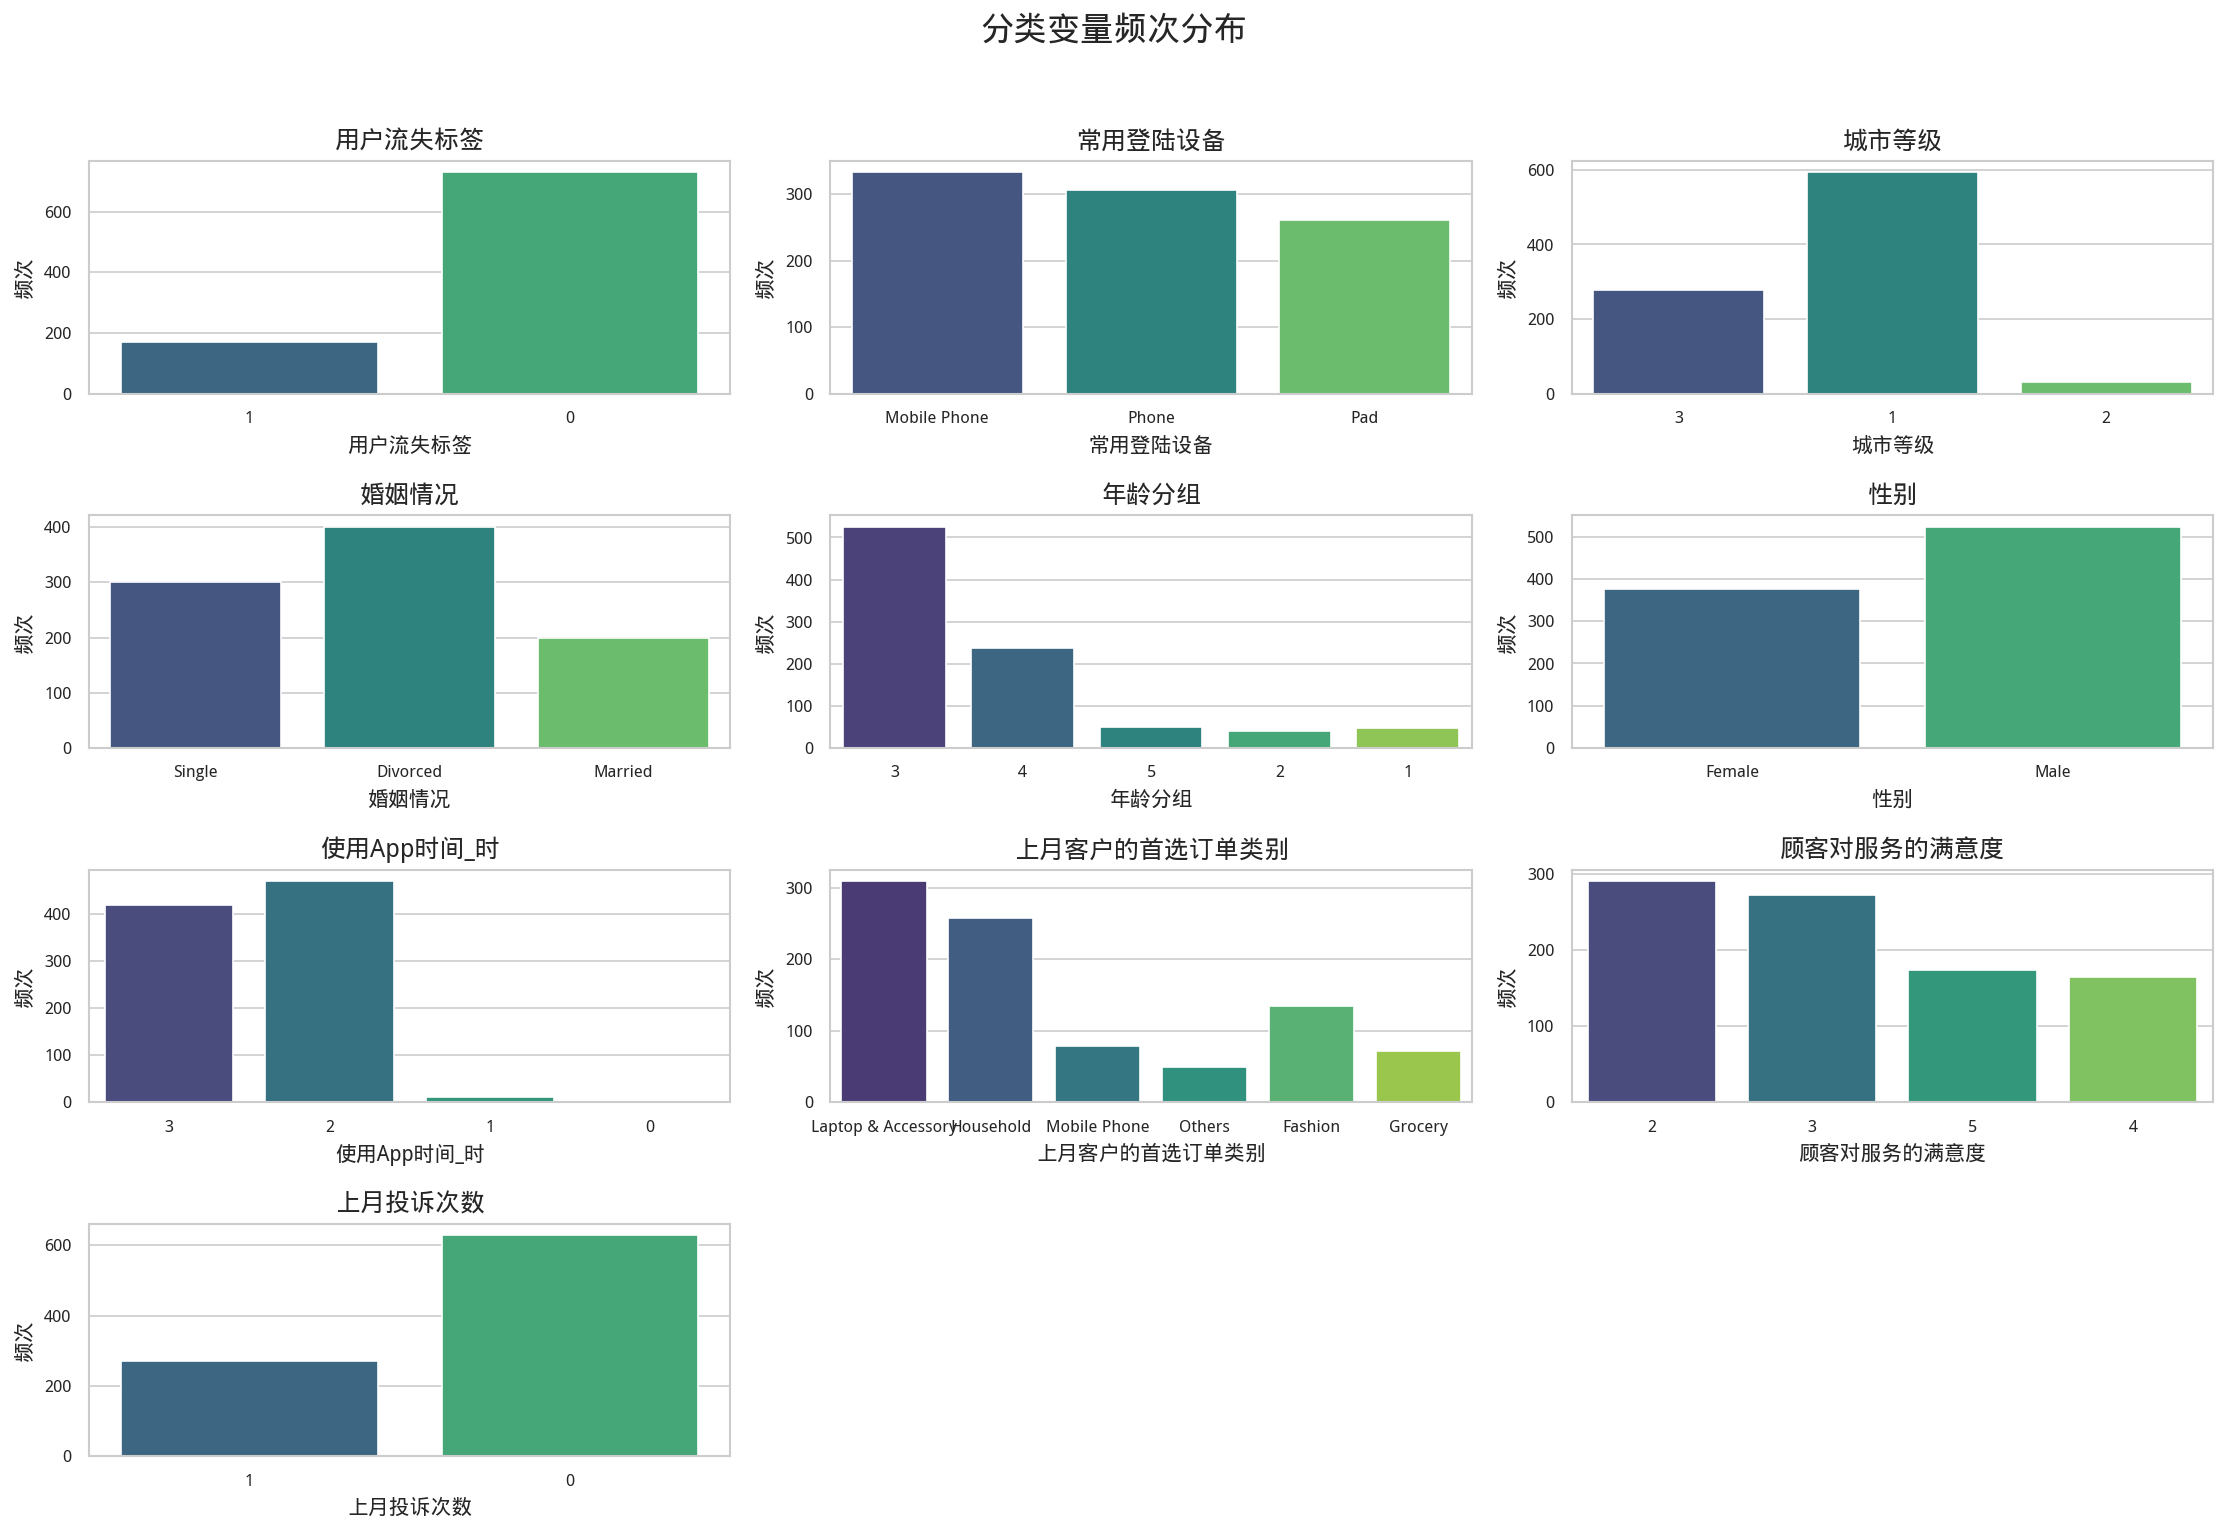

In [27]:
 
# 1.5 数据可视化 - 分类变量
 

# 将数值型的分类变量转换为对象类型
categorical_numeric_cols = ['用户流失标签', '城市等级', '使用App时间_时', '上月投诉次数', '年龄分组', '顾客对服务的满意度']
for col in categorical_numeric_cols:
    if col in raw_df.columns:
        raw_df[col] = raw_df[col].astype(str)

# 获取所有分类变量
cat_cols = raw_df.select_dtypes(include=['object']).columns.tolist()

print(f"【分类变量概览】")
print(f"分类变量数量: {len(cat_cols)}")
print(f"分类变量列表: {cat_cols}")

print("\n【分类变量分布】")
plot_countplots(raw_df, cat_cols, title="分类变量频次分布")

# 二、数据处理

## （一）将数据筛选

In [28]:
 
# Section 2: 数据处理与特征工程
 

 
# 2.1 数据筛选
 
# 深复制原始数据，创建工作副本
df = deepcopy(raw_df)

# 删除顾客ID（分析不需要）
if '顾客ID' in df.columns:
    df.drop('顾客ID', axis=1, inplace=True)

# 创建混合编码副本（后续用于混合编码）
mixed_df = deepcopy(df)

# 标准化副本（后续用于标准化）
standard_df = deepcopy(df)

# 识别分类列和数值列
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()

# 原始数值列（用于后续标准化）
raw_numeric_cols = [col for col in raw_df.select_dtypes(include=['number']).columns if col not in ['顾客ID', '用户流失标签']]

print(f"【数据预处理概览】")
print(f"总列数: {len(df.columns)}")
print(f"分类特征数量: {len(categorical_cols)}")
print(f"数值特征数量: {len(numeric_cols)}")
print(f"\n分类特征: {categorical_cols}")
print(f"\n数值特征: {numeric_cols}")

【数据预处理概览】
总列数: 18
分类特征数量: 10
数值特征数量: 8

分类特征: ['用户流失标签', '常用登陆设备', '城市等级', '婚姻情况', '年龄分组', '性别', '使用App时间_时', '上月客户的首选订单类别', '顾客对服务的满意度', '上月投诉次数']

数值特征: ['使用平台时间_月', '仓库到顾客地址', '上月订单数量单', '订单数量较去年增加_单', '距上次下单天数_天', '用户关注的主播数量', '上月使用的优惠劵数量_张', '上月平均折扣金额']


## （二）数值变量离散化

### 1、自定义分箱

In [29]:
# 示例离散化方法（根据业务理解调整分箱逻辑）
# def discretize_data(df):
#     # 使用平台时间（月）
#     df['平台时长分组'] = pd.cut(df['使用平台时间_月'],
#                               bins=[0, 3, 6, 12, 100],
#                               labels=['新用户','成长用户','成熟用户','老用户'])
    
#     # 距上次下单天数
#     df['最近活跃度'] = pd.cut(df['距上次下单天数_天'],
#                            bins=[-1, 3, 7, 15, 1000],
#                            labels=['高活跃','中活跃','低活跃','沉默'])
    
#     # 投诉次数
#     df['投诉情况'] = np.where(df['上月投诉次数']>0, '有投诉', '无投诉')
    
#     # 折扣金额
#     df['折扣力度'] = pd.qcut(df['上月平均折扣金额'], 
#                            q=4,
#                            labels=['低折扣','中等折扣','较高折扣','高折扣'])
    
#     return df

# df_preprocessed = discretize_data(df)

### 2、聚类分箱：Mean Shift 密度聚类：网格搜索参数优化

使用mean shift算法聚类分箱，使用网格搜索进行最佳宽带搜索

In [30]:
 
# 2.2 数值变量离散化 - Mean Shift 密度聚类
 
# 理论背景：
# - Mean Shift 是一种基于密度的非参数聚类算法
# - 通过寻找概率密度函数的局部极大值来确定聚类中心
# - 自适应确定簇的数量，无需预先指定聚类数
 

def evaluate_mean_shift(X, bandwidth, bin_seeding):
    """
    评估MeanShift聚类质量
    
    参数:
        X: 输入数据（已标准化）
        bandwidth: 带宽参数
        bin_seeding: 是否使用种子点加速
    
    返回:
        tuple: (轮廓系数, Calinski-Harabasz指数, 聚类数)
    """
    model = MeanShift(bandwidth=bandwidth, bin_seeding=bin_seeding, n_jobs=-1)
    labels = model.fit_predict(X)

    n_clusters = len(np.unique(labels))
    if n_clusters < 2:
        return (-1, -1, n_clusters)

    try:
        sil_score = silhouette_score(X, labels)
    except:
        sil_score = -1

    try:
        ch_score = calinski_harabasz_score(X, labels)
    except:
        ch_score = -1

    return sil_score, ch_score, n_clusters

def mean_shift_binning_optimized(df, cols, verbose=True):
    """
    对数值列进行Mean Shift聚类分箱（网格搜索优化）
    
    参数:
        df: 数据框
        cols: 要分箱的数值列列表
        verbose: 是否打印详细信息
    
    返回:
        df: 分箱后的数据框
        results_df: 最佳参数组合数据框
        metrics_df: 评价指标数据框
    """
    best_params_list = []
    evaluation_metrics_list = []
    
    start_time = time.time()
    
    for i, col in enumerate(cols):
        if verbose:
            print(f"\n处理列 {i+1}/{len(cols)}: {col}")
        
        # 准备数据
        X = df[[col]].values
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        # 预估带宽范围
        base_bandwidth = estimate_bandwidth(X_scaled, quantile=0.2, n_samples=500)
        
        # 参数网格
        param_grid = {
            'bandwidth': np.linspace(base_bandwidth * 0.5, base_bandwidth * 2.0, 10),
            'bin_seeding': [True, False]
        }
        
        # 网格搜索
        results = []
        for params in ParameterGrid(param_grid):
            sil, ch, n_clusters = evaluate_mean_shift(
                X_scaled, 
                params['bandwidth'], 
                params['bin_seeding']
            )
            results.append({
                'bandwidth': params['bandwidth'],
                'bin_seeding': params['bin_seeding'],
                'silhouette': sil,
                'calinski_harabasz': ch,
                'n_clusters': n_clusters
            })
        
        # 选择最佳参数
        results_df = pd.DataFrame(results)
        valid_results = results_df[results_df['silhouette'] > 0].copy()
        
        if valid_results.empty:
            print(f"  警告: {col} 未找到有效聚类，使用默认参数")
            best_params = {'bandwidth': base_bandwidth, 'bin_seeding': True, 'silhouette': 0, 'n_clusters': 1}
        else:
            # 综合评分
            valid_results.loc[:, 'composite_score'] = (
                0.6 * valid_results['silhouette'] +
                0.3 * valid_results['calinski_harabasz'] / 1000 +
                0.1 * valid_results['n_clusters']
            )
            best_params = valid_results.loc[valid_results['composite_score'].idxmax()]
        
        # 记录结果
        best_params_list.append({
            '列名': col,
            '带宽': best_params['bandwidth'],
            '种子加速': best_params['bin_seeding'],
            '轮廓系数': best_params['silhouette'],
            '聚类数': best_params['n_clusters']
        })
        
        # 应用聚类
        ms = MeanShift(bandwidth=best_params['bandwidth'], bin_seeding=best_params['bin_seeding'], n_jobs=-1)
        clusters = ms.fit_predict(X_scaled)
        
        # 将聚类结果作为新特征（转换为字符串以避免与原始列混淆）
        df[col] = clusters.astype(str)
    
    end_time = time.time()
    
    # 转换为DataFrame
    results_df = pd.DataFrame(best_params_list)
    metrics_df = pd.DataFrame(best_params_list)[['列名', '轮廓系数', '聚类数']]
    
    if verbose:
        print(f"\n{'='*60}")
        print(f"Mean Shift 分箱完成，耗时: {end_time - start_time:.2f}秒")
        print(f"{'='*60}")
        print("\n【最佳参数组合】")
        print(results_df.round({'带宽': 3, '轮廓系数': 3}))
        print("\n【评价指标】")
        print(metrics_df.round({'轮廓系数': 3}))
    
    return df, results_df, metrics_df

# 执行分箱
# 获取需要分箱的数值列（排除用户流失标签）
num_cols_to_bin = [col for col in raw_numeric_cols if col in df.columns]

print("【Mean Shift 密度聚类分箱】")
print(f"将分箱 {len(num_cols_to_bin)} 个数值特征...")

df, best_params_df, evaluation_metrics_df = mean_shift_binning_optimized(df, num_cols_to_bin, verbose=True)

print(f"\n【分箱结果验证】")
print(f"分箱后数据类型: {df.dtypes.unique()}")

【Mean Shift 密度聚类分箱】
将分箱 8 个数值特征...

处理列 1/8: 使用平台时间_月

处理列 2/8: 仓库到顾客地址

处理列 3/8: 上月订单数量单

处理列 4/8: 订单数量较去年增加_单

处理列 5/8: 距上次下单天数_天

处理列 6/8: 用户关注的主播数量

处理列 7/8: 上月使用的优惠劵数量_张

处理列 8/8: 上月平均折扣金额

Mean Shift 分箱完成，耗时: 38.19秒

【最佳参数组合】
             列名     带宽   种子加速   轮廓系数  聚类数
0      使用平台时间_月  0.187  False  0.705   12
1       仓库到顾客地址  0.199  False  0.719   13
2       上月订单数量单  0.170   True  1.000   15
3   订单数量较去年增加_单  0.219  False  1.000   15
4     距上次下单天数_天  0.170   True  0.999   18
5     用户关注的主播数量  0.186   True  0.998   12
6  上月使用的优惠劵数量_张  0.152   True  0.996   15
7      上月平均折扣金额  0.204  False  0.590   10

【评价指标】
             列名   轮廓系数  聚类数
0      使用平台时间_月  0.705   12
1       仓库到顾客地址  0.719   13
2       上月订单数量单  1.000   15
3   订单数量较去年增加_单  1.000   15
4     距上次下单天数_天  0.999   18
5     用户关注的主播数量  0.998   12
6  上月使用的优惠劵数量_张  0.996   15
7      上月平均折扣金额  0.590   10

【分箱结果验证】
分箱后数据类型: [dtype('O')]


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 901 entries, 0 to 900
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   用户流失标签        901 non-null    object
 1   使用平台时间_月      901 non-null    object
 2   常用登陆设备        901 non-null    object
 3   城市等级          901 non-null    object
 4   仓库到顾客地址       901 non-null    object
 5   婚姻情况          901 non-null    object
 6   年龄分组          901 non-null    object
 7   性别            901 non-null    object
 8   使用App时间_时     901 non-null    object
 9   上月订单数量单       901 non-null    object
 10  订单数量较去年增加_单   901 non-null    object
 11  距上次下单天数_天     901 non-null    object
 12  上月客户的首选订单类别   901 non-null    object
 13  用户关注的主播数量     901 non-null    object
 14  顾客对服务的满意度     901 non-null    object
 15  上月投诉次数        901 non-null    object
 16  上月使用的优惠劵数量_张  901 non-null    object
 17  上月平均折扣金额      901 non-null    object
dtypes: object(18)
memory usage: 126.8+ KB


## （三）变量热编码

### 1、对 df 进行全热编码

In [32]:
 
# 2.3 特征编码
 

def one_hot_encode(df, drop_first=True):
    """
    对数据框进行独热编码
    
    参数:
        df: 数据框
        drop_first: 是否删除每个分类变量的第一列（避免虚拟变量陷阱）
    
    返回:
        df_encoded: 编码后的数据框
    """
    df_encoded = pd.get_dummies(df, drop_first=drop_first)
    
    # 将布尔值转换为整数
    bool_columns = df_encoded.select_dtypes(include='bool').columns
    df_encoded[bool_columns] = df_encoded[bool_columns].astype(int)
    
    return df_encoded

# 对 df 进行全热编码
print("【全热编码】")
df_encoded = one_hot_encode(df, drop_first=True)
print(f"编码后维度: {df_encoded.shape[0]} 行 × {df_encoded.shape[1]} 列")
print(f"列名示例: {list(df_encoded.columns[:5])}")

【全热编码】
编码后维度: 901 行 × 126 列
列名示例: ['用户流失标签_1', '使用平台时间_月_1', '使用平台时间_月_10', '使用平台时间_月_11', '使用平台时间_月_2']


### 2、对df1分类变量进行哑变量操作；连续数值进行最大最小正则化

In [33]:
# 混合编码：分类变量独热编码 + 数值变量标准化
print("【混合编码处理】")
print("  - 分类变量: 独热编码")
print("  - 数值变量: Min-Max标准化")

# 分类变量独热编码
df_categorical = pd.get_dummies(mixed_df[categorical_cols], drop_first=True)
bool_columns = df_categorical.select_dtypes(include='bool').columns
df_categorical[bool_columns] = df_categorical[bool_columns].astype(int)

# 数值变量 Min-Max 标准化
scaler_minmax = MinMaxScaler()
df_numeric_minmax = mixed_df[raw_numeric_cols]
df_numeric_scaled_minmax = pd.DataFrame(
    scaler_minmax.fit_transform(df_numeric_minmax),
    columns=df_numeric_minmax.columns,
    index=df_numeric_minmax.index
)

# 合并
mixed_df = pd.concat([df_categorical, df_numeric_scaled_minmax], axis=1)
print(f"混合编码后维度: {mixed_df.shape[0]} 行 × {mixed_df.shape[1]} 列")

【混合编码处理】
  - 分类变量: 独热编码
  - 数值变量: Min-Max标准化
混合编码后维度: 901 行 × 32 列


### 3、对df3只进行数值标准化

In [34]:
# 标准化处理：分类变量保留 + 数值变量Z-score标准化
print("【标准化处理】")
print("  - 分类变量: 保留原始值")
print("  - 数值变量: Z-score标准化")

# 数值变量 Z-score 标准化
scaler_standard = StandardScaler()
df_numeric_scaled = pd.DataFrame(
    scaler_standard.fit_transform(standard_df[raw_numeric_cols]),
    columns=raw_numeric_cols,
    index=standard_df.index
)

# 合并分类变量和标准化数值变量
standard_df = pd.concat([standard_df[categorical_cols], df_numeric_scaled], axis=1)
print(f"标准化后维度: {standard_df.shape[0]} 行 × {standard_df.shape[1]} 列")

【标准化处理】
  - 分类变量: 保留原始值
  - 数值变量: Z-score标准化
标准化后维度: 901 行 × 18 列


# 三、灰色关联分析

## （一）APRIOT与FP-Growth

In [35]:
 
# 三、关联规则挖掘
 
# 理论背景：
# - 关联规则挖掘用于发现数据项之间的关联关系
# - 支持度(Support): P(A∪B) - 项集在数据中出现的频率
# - 置信度(Confidence): P(B|A) = P(A∪B)/P(A) - 出现A的条件下也出现B的概率
# - 提升度(Lift): P(B|A)/P(B) - 衡量关联强度，>1表示正相关，<1表示负相关，=1表示独立
 

 
# （一）Apriori 与 FP-Growth 算法
 

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

# 1. 数据准备 - 正确构建事务列表
# 关键修复：直接使用 df_encoded 的列名，而不是创建新的字符串标签
def prepare_transaction_data(df_encoded, target_col='用户流失标签_1'):
    """
    准备事务数据用于关联规则挖掘
    
    参数:
        df_encoded: 经过独热编码的数据框
        target_col: 目标列名（如用户流失标签）
    
    返回:
        df_trans: 转换后的事务数据框
        te: TransactionEncoder对象
    """
    transactions = []
    for _, row in df_encoded.iterrows():
        # 只添加值为1的列名（即出现的特征）
        transaction = [col for col in df_encoded.columns if row[col] == 1]
        transactions.append(transaction)
    
    # 使用 TransactionEncoder 进行编码
    te = TransactionEncoder()
    te_ary = te.fit(transactions).transform(transactions)
    df_trans = pd.DataFrame(te_ary, columns=te.columns_)
    
    print(f"事务数据构建完成，共 {len(transactions)} 条事务")
    print(f"唯一项数量: {len(te.columns_)}")
    print(f"目标列 '{target_col}' 是否在列中: {target_col in te.columns_}")
    
    return df_trans, te

# 准备事务数据
df_trans, te = prepare_transaction_data(df_encoded, target_col='用户流失标签_1')

# 2. 参数设置
min_support = 0.02      # 最小支持度（频繁项集必须出现在至少2%的事务中）
min_threshold = 0.3     # 最小置信度

# 3. 使用 Apriori 算法挖掘频繁项集
print("\n【Apriori 算法】正在挖掘频繁项集...")
start_time = time.time()
apriori_frequent_itemsets = apriori(df_trans, min_support=min_support, use_colnames=True, max_len=3)
apriori_time = time.time() - start_time
print(f"Apriori 耗时: {apriori_time:.2f}秒，发现 {len(apriori_frequent_itemsets)} 个频繁项集")

# 4. 使用 FP-Growth 算法挖掘频繁项集
print("\n【FP-Growth 算法】正在挖掘频繁项集...")
start_time = time.time()
fpgrowth_frequent_itemsets = fpgrowth(df_trans, min_support=min_support, use_colnames=True, max_len=3)
fpgrowth_time = time.time() - start_time
print(f"FP-Growth 耗时: {fpgrowth_time:.2f}秒，发现 {len(fpgrowth_frequent_itemsets)} 个频繁项集")

# 5. 生成关联规则并筛选
def filter_churn_rules(rules_df, target_col='用户流失标签_1', lift_threshold=1.0):
    """
    筛选与目标（客户流失）相关的关联规则
    
    参数:
        rules_df: 关联规则数据框
        target_col: 目标列名
        lift_threshold: 最小提升度阈值
    
    返回:
        筛选后的规则数据框
    """
    if rules_df.empty:
        return rules_df
    
    # 筛选包含目标列的规则（检查consequents列）
    # 关键修复：正确处理frozenset类型的列
    churn_rules = rules_df[rules_df['consequents'].apply(lambda x: target_col in x)]
    
    # 进一步筛选提升度 > 1 的规则（表示正相关）
    churn_rules = churn_rules[churn_rules['lift'] > lift_threshold]
    
    return churn_rules

# 为 Apriori 生成关联规则
print("\n【Apriori】生成关联规则...")
apriori_rules = association_rules(
    apriori_frequent_itemsets, 
    metric="confidence", 
    min_threshold=min_threshold
)
apriori_rules = apriori_rules[apriori_rules['lift'] > 1]

# 为 FP-Growth 生成关联规则
print("【FP-Growth】生成关联规则...")
fpgrowth_rules = association_rules(
    fpgrowth_frequent_itemsets, 
    metric="confidence", 
    min_threshold=min_threshold
)
fpgrowth_rules = fpgrowth_rules[fpgrowth_rules['lift'] > 1]

# 筛选与客户流失相关的规则
target_col = '用户流失标签_1'
apriori_churn_rules = filter_churn_rules(apriori_rules, target_col)
fpgrowth_churn_rules = filter_churn_rules(fpgrowth_rules, target_col)

# 6. 结果展示
print("=" * 80)
print("【算法性能对比】")
print("=" * 80)
comparison_data = {
    '算法': ['Apriori', 'FP-Growth'],
    '耗时(秒)': [f"{apriori_time:.2f}", f"{fpgrowth_time:.2f}"],
    '频繁项集数': [len(apriori_frequent_itemsets), len(fpgrowth_frequent_itemsets)],
    '总关联规则数': [len(apriori_rules), len(fpgrowth_rules)],
    '流失相关规则数': [len(apriori_churn_rules), len(fpgrowth_churn_rules)]
}
comparison_df = pd.DataFrame(comparison_data)
q(comparison_df)

print("\n" + "=" * 80)
print(f"【Apriori - 与客户流失相关的关联规则】({len(apriori_churn_rules)} 条)")
print("=" * 80)
if len(apriori_churn_rules) > 0:
    display_rules = apriori_churn_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].copy()
    display_rules = display_rules.sort_values('lift', ascending=False)
    q(display_rules.head(10))
else:
    print("未找到与客户流失相关的关联规则（可能是参数设置过严格）")

print("\n" + "=" * 80)
print(f"【FP-Growth - 与客户流失相关的关联规则】({len(fpgrowth_churn_rules)} 条)")
print("=" * 80)
if len(fpgrowth_churn_rules) > 0:
    display_rules = fpgrowth_churn_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].copy()
    display_rules = display_rules.sort_values('lift', ascending=False)
    q(display_rules.head(10))
else:
    print("未找到与客户流失相关的关联规则（可能是参数设置过严格）")

# 7. 业务洞察提取
def extract_insights_from_rules(rules_df, top_n=5):
    """
    从关联规则中提取业务洞察
    
    参数:
        rules_df: 关联规则数据框
        top_n: 返回前N条规则
    
    返回:
        insights_str: 业务洞察文本
    """
    if rules_df.empty:
        return "未发现有效关联规则"
    
    # 按提升度排序
    sorted_rules = rules_df.sort_values('lift', ascending=False).head(top_n)
    
    insights = []
    insights.append("【关键发现】")
    insights.append(f"从关联规则分析中，提取出 {len(sorted_rules)} 条与客户流失最相关的规则：\n")
    
    for idx, row in sorted_rules.iterrows():
        antecedents = list(row['antecedents'])
        # 排除目标列本身
        factors = [x for x in antecedents if x != target_col]
        if factors:
            insight = f"- {', '.join(factors)} → 客户流失 (Lift={row['lift']:.2f}, 置信度={row['confidence']:.2%})"
            insights.append(insight)
    
    insights.append("\n【行动建议】")
    insights.append("1. 对高流失风险客户进行提前干预和关怀")
    insights.append("2. 分析关键因素背后的业务问题（如投诉处理、服务质量等）")
    insights.append("3. 针对性地优化产品和服务流程")
    
    return '\n'.join(insights)

print("\n" + "=" * 80)
print("【业务洞察】")
print("=" * 80)
print(extract_insights_from_rules(fpgrowth_churn_rules, top_n=5))

事务数据构建完成，共 901 条事务
唯一项数量: 126
目标列 '用户流失标签_1' 是否在列中: True

【Apriori 算法】正在挖掘频繁项集...
Apriori 耗时: 0.07秒，发现 2072 个频繁项集

【FP-Growth 算法】正在挖掘频繁项集...
FP-Growth 耗时: 2.92秒，发现 2072 个频繁项集

【Apriori】生成关联规则...
【FP-Growth】生成关联规则...
【算法性能对比】


,算法,耗时(秒),频繁项集数,总关联规则数,流失相关规则数
0,Apriori,0.07,2072,2485,56
1,FP-Growth,2.92,2072,2485,56



【Apriori - 与客户流失相关的关联规则】(56 条)


,antecedents,consequents,support,confidence,lift
1088,"(上月投诉次数_1, 上月客户的首选订单类别_Household)",(用户流失标签_1),0.056604,0.593023,3.106476
2239,"(上月投诉次数_1, 距上次下单天数_天_1)",(用户流失标签_1),0.033296,0.588235,3.081395
2033,"(上月投诉次数_1, 仓库到顾客地址_4)",(用户流失标签_1),0.024417,0.564103,2.954979
2151,"(上月投诉次数_1, 婚姻情况_Single)",(用户流失标签_1),0.055494,0.549451,2.878226
1333,"(上月客户的首选订单类别_Household, 距上次下单天数_天_1)",(用户流失标签_1),0.035516,0.507937,2.660760
3130,"(婚姻情况_Single, 距上次下单天数_天_1)",(用户流失标签_1),0.034406,0.476923,2.498301
1004,"(上月使用的优惠劵数量_张_1, 距上次下单天数_天_1)",(用户流失标签_1),0.029967,0.473684,2.481334
573,(年龄分组_5),(用户流失标签_1),0.024417,0.448980,2.351922
3137,"(顾客对服务的满意度_5, 婚姻情况_Single)",(用户流失标签_1),0.026637,0.444444,2.328165
1338,"(顾客对服务的满意度_5, 上月客户的首选订单类别_Household)",(用户流失标签_1),0.022198,0.444444,2.328165



【FP-Growth - 与客户流失相关的关联规则】(56 条)


,antecedents,consequents,support,confidence,lift
547,"(上月投诉次数_1, 上月客户的首选订单类别_Household)",(用户流失标签_1),0.056604,0.593023,3.106476
1285,"(上月投诉次数_1, 距上次下单天数_天_1)",(用户流失标签_1),0.033296,0.588235,3.081395
2981,"(上月投诉次数_1, 仓库到顾客地址_4)",(用户流失标签_1),0.024417,0.564103,2.954979
488,"(上月投诉次数_1, 婚姻情况_Single)",(用户流失标签_1),0.055494,0.549451,2.878226
1234,"(上月客户的首选订单类别_Household, 距上次下单天数_天_1)",(用户流失标签_1),0.035516,0.507937,2.660760
1237,"(婚姻情况_Single, 距上次下单天数_天_1)",(用户流失标签_1),0.034406,0.476923,2.498301
1251,"(上月使用的优惠劵数量_张_1, 距上次下单天数_天_1)",(用户流失标签_1),0.029967,0.473684,2.481334
2026,(年龄分组_5),(用户流失标签_1),0.024417,0.448980,2.351922
660,"(顾客对服务的满意度_5, 上月客户的首选订单类别_Household)",(用户流失标签_1),0.022198,0.444444,2.328165
652,"(顾客对服务的满意度_5, 婚姻情况_Single)",(用户流失标签_1),0.026637,0.444444,2.328165



【业务洞察】
【关键发现】
从关联规则分析中，提取出 5 条与客户流失最相关的规则：

- 上月投诉次数_1, 上月客户的首选订单类别_Household → 客户流失 (Lift=3.11, 置信度=59.30%)
- 上月投诉次数_1, 距上次下单天数_天_1 → 客户流失 (Lift=3.08, 置信度=58.82%)
- 上月投诉次数_1, 仓库到顾客地址_4 → 客户流失 (Lift=2.95, 置信度=56.41%)
- 上月投诉次数_1, 婚姻情况_Single → 客户流失 (Lift=2.88, 置信度=54.95%)
- 上月客户的首选订单类别_Household, 距上次下单天数_天_1 → 客户流失 (Lift=2.66, 置信度=50.79%)

【行动建议】
1. 对高流失风险客户进行提前干预和关怀
2. 分析关键因素背后的业务问题（如投诉处理、服务质量等）
3. 针对性地优化产品和服务流程


整体结果分析
强关联因素：
从 lift 值来看，(上月投诉次数_1, 上月客户的首选订单类别_Household) 这条规则的 lift 值为 3.106476，是所有规则中最高的，说明上月有投诉且首选订单类别为家居用品的客户流失的可能性显著增加。
(上月投诉次数_1) 这条规则的 lift 值为 1.848837，也表明上月有投诉的客户更容易流失。
业务建议：
对于家居用品订单类别，可优化服务质量，减少客户投诉，例如加强商品质量把控、提高物流速度等。
建立客户投诉反馈机制，及时处理客户投诉，提高客户满意度，从而降低客户流失率。

## （二）FP-Growth参数优化：随机搜索

### 1、结合多种关联规则质量指标的加权评分函数

In [36]:
 
# （二）FP-Growth 参数优化：随机搜索
 

def rule_quality_score(rules):
    """
    结合多种关联规则质量指标的加权评分函数
    
    评估指标说明：
    - support: 支持度 - 项集在数据中出现的频率
    - confidence: 置信度 - 条件概率
    - lift: 提升度 - 衡量关联强度
    - kulczynski: 度量指标 - 平衡性和鲁棒性
    - ir: 不平衡比率 - 衡量项集出现频率的不平衡性
    
    参数:
        rules: 关联规则数据框
    
    返回:
        score: 综合评分
    """
    if rules.empty:
        return -np.inf
    
    # 归一化处理
    support_max = rules['support'].max() if rules['support'].max() > 0 else 1
    confidence_max = rules['confidence'].max() if rules['confidence'].max() > 0 else 1
    lift_max = rules['lift'].max() if rules['lift'].max() > 0 else 1

    norm_support = rules['support'] / support_max
    norm_confidence = rules['confidence'] / confidence_max
    norm_lift = rules['lift'] / lift_max

    # Kulczynski 度量
    kulc = (rules['confidence'] + rules.apply(
        lambda row: rules.loc[
            (rules['antecedents'] == frozenset(row['consequents'])) &
            (rules['consequents'] == frozenset(row['antecedents']))
        ]['confidence'].values[0] if len(rules.loc[
            (rules['antecedents'] == frozenset(row['consequents'])) &
            (rules['consequents'] == frozenset(row['antecedents']))
        ]) > 0 else 0, axis=1)) / 2

    # 不平衡比率
    antecedent_support = rules['antecedent support']
    consequent_support = rules['consequent support']
    ir = abs(antecedent_support - consequent_support) / (antecedent_support + consequent_support + 1e-8)

    all_confidence = rules[['confidence', 'antecedent support']].min(axis=1)
    max_confidence = rules[['confidence', 'antecedent support']].max(axis=1)

    kulc_norm = (kulc - kulc.min()) / (kulc.max() - kulc.min() + 1e-8) if not kulc.isna().all() else 0

    # 综合评分公式
    score = (
        0.2 * norm_support +      # 支持度权重
        0.2 * norm_confidence +  # 置信度权重
        0.2 * norm_lift +         # 提升度权重
        0.1 * kulc_norm +         # Kulczynski度量权重
        0.1 * (1 - ir) +          # 不平衡比率权重（越小越好）
        0.1 * all_confidence +    # 最大置信度权重
        0.1 * max_confidence      # 最小置信度权重
    )

    return score.mean()

def optimize_fpgrowth_params(df, param_space, target_col='用户流失标签_1', n_iter=10):
    """
    使用随机搜索优化FP-Growth参数
    
    参数:
        df: 事务数据框（经过TransactionEncoder编码）
        param_space: 参数空间字典
        target_col: 目标列名
        n_iter: 迭代次数
    
    返回:
        dict: 包含最佳参数、最佳规则等的结果字典
    """
    best_score = -np.inf
    best_params = None
    best_rules = None
    all_num_rules = []
    
    param_list = list(ParameterSampler(param_space, n_iter=n_iter))
    
    start_time = time.time()
    
    print(f"【第一轮】统计各参数下的规则数量...")
    for params in param_list:
        min_support = params['min_support']
        min_threshold = params['min_threshold']
        
        frequent_itemsets = fpgrowth(df, min_support=min_support, use_colnames=True)
        if frequent_itemsets.empty:
            all_num_rules.append(0)
            continue
        
        rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=min_threshold)
        
        # 筛选与目标相关的规则
        churn_rules = rules[rules['consequents'].apply(lambda x: target_col in x)]
        churn_rules = churn_rules[churn_rules['lift'] > 1]
        
        all_num_rules.append(len(churn_rules))
    
    global_max_rules = max(all_num_rules) if any(x > 0 for x in all_num_rules) else 1
    print(f"最大规则数量为：{global_max_rules}")
    
    print(f"\n【第二轮】正式运行随机搜索...\n")
    for i, params in enumerate(param_list):
        min_support = params['min_support']
        min_threshold = params['min_threshold']
        
        frequent_itemsets = fpgrowth(df, min_support=min_support, use_colnames=True)
        if frequent_itemsets.empty:
            continue
        
        rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=min_threshold)
        
        # 评估规则质量
        if rules.empty:
            continue
            
        churn_rules = rules[rules['consequents'].apply(lambda x: target_col in x)]
        churn_rules = churn_rules[churn_rules['lift'] > 1]
        
        if churn_rules.empty:
            score = -np.inf
        else:
            # 规则质量评分
            quality_score = rule_quality_score(churn_rules)
            # 规则数量权重
            rule_count_weight = np.clip(len(churn_rules) / global_max_rules, 0, 1)
            score = quality_score * rule_count_weight
        
        print(f"参数 {i+1}/{n_iter}: {params}, 得分: {score:.4f}, 规则数: {len(churn_rules)}")
        
        if score > best_score:
            best_score = score
            best_params = params.copy()
            best_rules = rules.copy()
    
    end_time = time.time()
    
    return {
        'best_params': best_params,
        'best_rules': best_rules,
        'best_score': best_score,
        'elapsed_time': end_time - start_time
    }

# 参数空间设计
param_space = {
    'min_support': np.geomspace(0.02, 0.2, num=8),
    'min_threshold': np.linspace(0.3, 0.7, 5)
}

# 运行参数优化
target_col = '用户流失标签_1'
optimization_result = optimize_fpgrowth_params(df_trans, param_space, target_col, n_iter=10)

print(f"\nFP-Growth 耗时: {optimization_result['elapsed_time']:.2f}s")
print("\n最佳参数组合:")
print(optimization_result['best_params'])

# 筛选最终规则
if optimization_result['best_rules'] is not None:
    final_churn_rules = optimization_result['best_rules'][
        optimization_result['best_rules']['consequents'].apply(lambda x: target_col in x)
    ]
    final_churn_rules = final_churn_rules[final_churn_rules['lift'] > 1]
    
    # 按提升度排序
    final_churn_rules = final_churn_rules.sort_values('lift', ascending=False)
    final_churn_rules = final_churn_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
    
    print(f"\n最终与客户流失相关的关联规则共计 {len(final_churn_rules)} 条：")
    q(final_churn_rules.head(10))
    
    # 提取业务洞察
    print("\n" + "=" * 80)
    print("【业务洞察】")
    print("=" * 80)
    print(extract_insights_from_rules(final_churn_rules, top_n=5))

【第一轮】统计各参数下的规则数量...
最大规则数量为：23

【第二轮】正式运行随机搜索...

参数 1/10: {'min_threshold': 0.7, 'min_support': 0.053653915905594526}, 得分: -inf, 规则数: 0
参数 2/10: {'min_threshold': 0.39999999999999997, 'min_support': 0.053653915905594526}, 得分: 0.0668, 规则数: 2
参数 3/10: {'min_threshold': 0.3, 'min_support': 0.053653915905594526}, 得分: 0.2464, 规则数: 10
参数 4/10: {'min_threshold': 0.39999999999999997, 'min_support': 0.10358949358462421}, 得分: -inf, 规则数: 0
参数 5/10: {'min_threshold': 0.7, 'min_support': 0.02}, 得分: 0.0637, 规则数: 2
参数 6/10: {'min_threshold': 0.5, 'min_support': 0.038613954577665}, 得分: 0.0945, 规则数: 3
参数 7/10: {'min_threshold': 0.5, 'min_support': 0.2}, 得分: -inf, 规则数: 0
参数 8/10: {'min_threshold': 0.5, 'min_support': 0.10358949358462421}, 得分: -inf, 规则数: 0
参数 9/10: {'min_threshold': 0.7, 'min_support': 0.2}, 得分: -inf, 规则数: 0
参数 10/10: {'min_threshold': 0.39999999999999997, 'min_support': 0.02778990988746275}, 得分: 0.5333, 规则数: 23

FP-Growth 耗时: 18.61s

最佳参数组合:
{'min_threshold': 0.39999999999999997, 'min_

,antecedents,consequents,support,confidence,lift
723,"(上月投诉次数_1, 上月客户的首选订单类别_Household)","(用户流失标签_1, 常用登陆设备_Phone)",0.038846,0.406977,5.164592
630,"(上月投诉次数_1, 婚姻情况_Single, 性别_Male)",(用户流失标签_1),0.033296,0.666667,3.492248
654,"(上月投诉次数_1, 婚姻情况_Single, 使用App时间_时_3)",(用户流失标签_1),0.029967,0.627907,3.289210
675,"(上月投诉次数_1, 上月客户的首选订单类别_Household)",(用户流失标签_1),0.056604,0.593023,3.106476
1279,"(上月投诉次数_1, 距上次下单天数_天_1)",(用户流失标签_1),0.033296,0.588235,3.081395
698,"(上月投诉次数_1, 年龄分组_3, 上月客户的首选订单类别_Household)",(用户流失标签_1),0.029967,0.586957,3.074697
694,"(上月投诉次数_1, 上月客户的首选订单类别_Household, 使用App时间_时_3)",(用户流失标签_1),0.031077,0.571429,2.993355
690,"(上月投诉次数_1, 上月客户的首选订单类别_Household, 性别_Male)",(用户流失标签_1),0.032186,0.568627,2.978682
624,"(上月投诉次数_1, 婚姻情况_Single)",(用户流失标签_1),0.055494,0.549451,2.878226
720,"(上月投诉次数_1, 上月客户的首选订单类别_Household, 常用登陆设备_Phone)",(用户流失标签_1),0.038846,0.538462,2.820662



【业务洞察】
【关键发现】
从关联规则分析中，提取出 5 条与客户流失最相关的规则：

- 上月投诉次数_1, 上月客户的首选订单类别_Household → 客户流失 (Lift=5.16, 置信度=40.70%)
- 上月投诉次数_1, 婚姻情况_Single, 性别_Male → 客户流失 (Lift=3.49, 置信度=66.67%)
- 上月投诉次数_1, 婚姻情况_Single, 使用App时间_时_3 → 客户流失 (Lift=3.29, 置信度=62.79%)
- 上月投诉次数_1, 上月客户的首选订单类别_Household → 客户流失 (Lift=3.11, 置信度=59.30%)
- 上月投诉次数_1, 距上次下单天数_天_1 → 客户流失 (Lift=3.08, 置信度=58.82%)

【行动建议】
1. 对高流失风险客户进行提前干预和关怀
2. 分析关键因素背后的业务问题（如投诉处理、服务质量等）
3. 针对性地优化产品和服务流程


与用户流失相关的因素包括上月客户的首选订单类别为 “Household”、上月投诉次数为 1、婚姻情况为 “Single”、常用登陆设备为 “Phone”、顾客对服务的满意度为 3、使用 App 时间为 3 小时、距上次下单天数为 1 天、城市等级为 3 等。这些因素与用户流失标签之间存在一定的关联关系，可能是导致用户流失的潜在因素。

# 四、聚类分析

## （一）K-Mean

【K-Means 聚类分析】


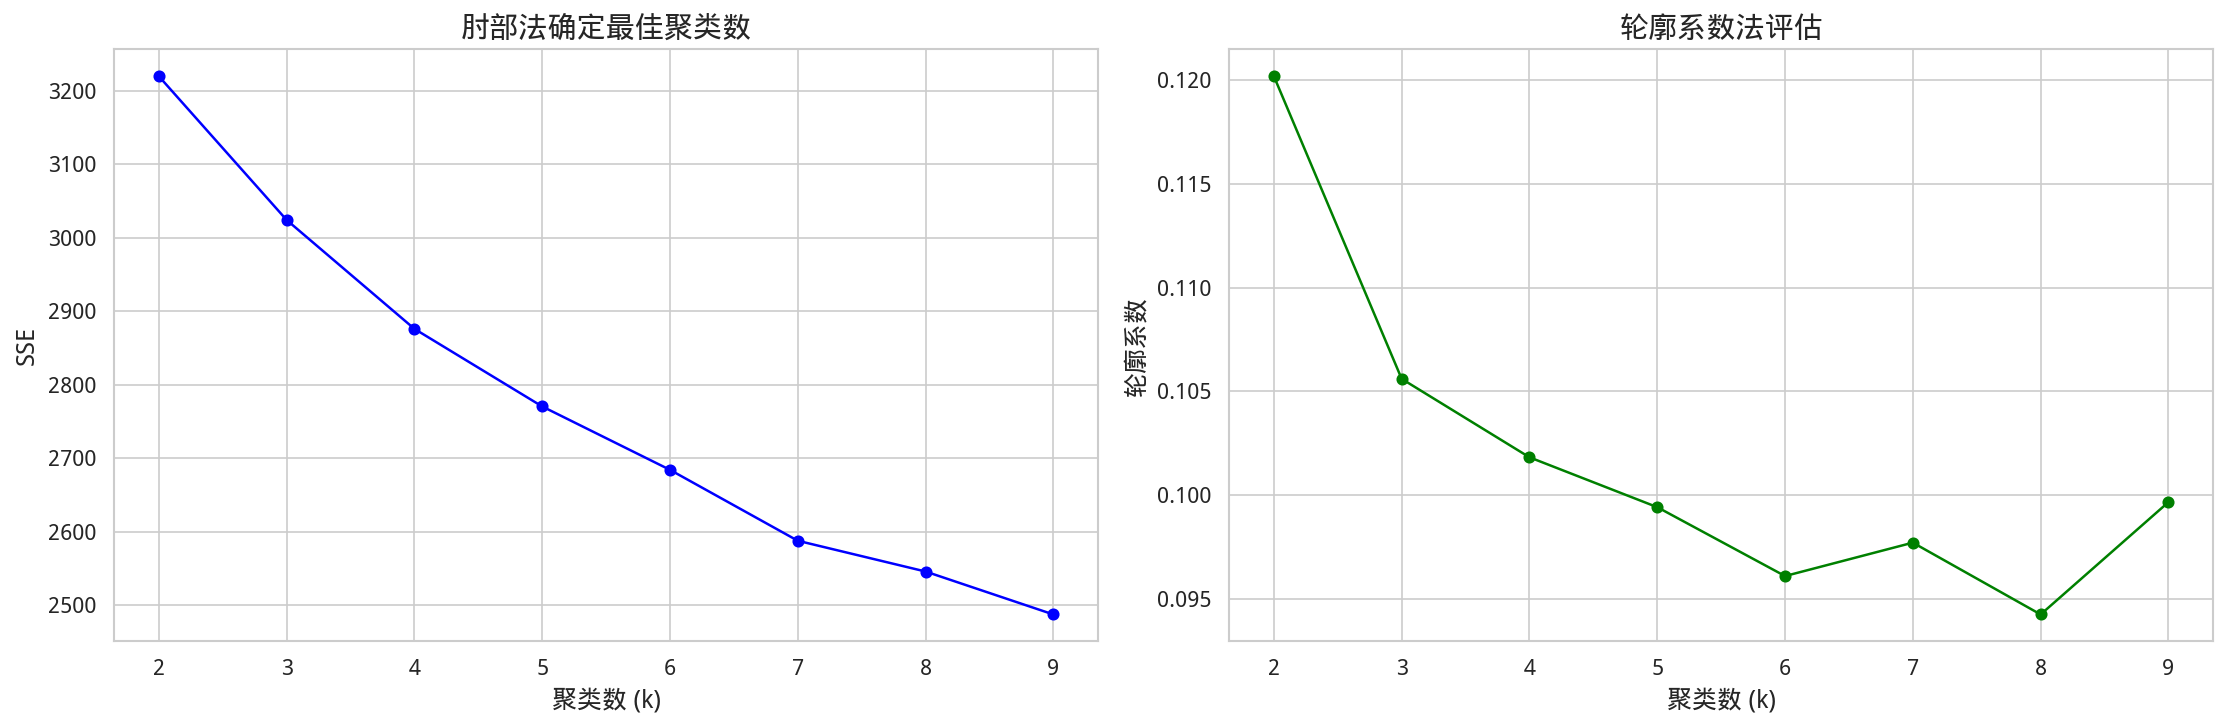

根据肘部法，最佳聚类数为: 7

【聚类评估】
轮廓系数: 0.0977
Calinski-Harabasz指数: 62.3638

【聚类特征轮廓】


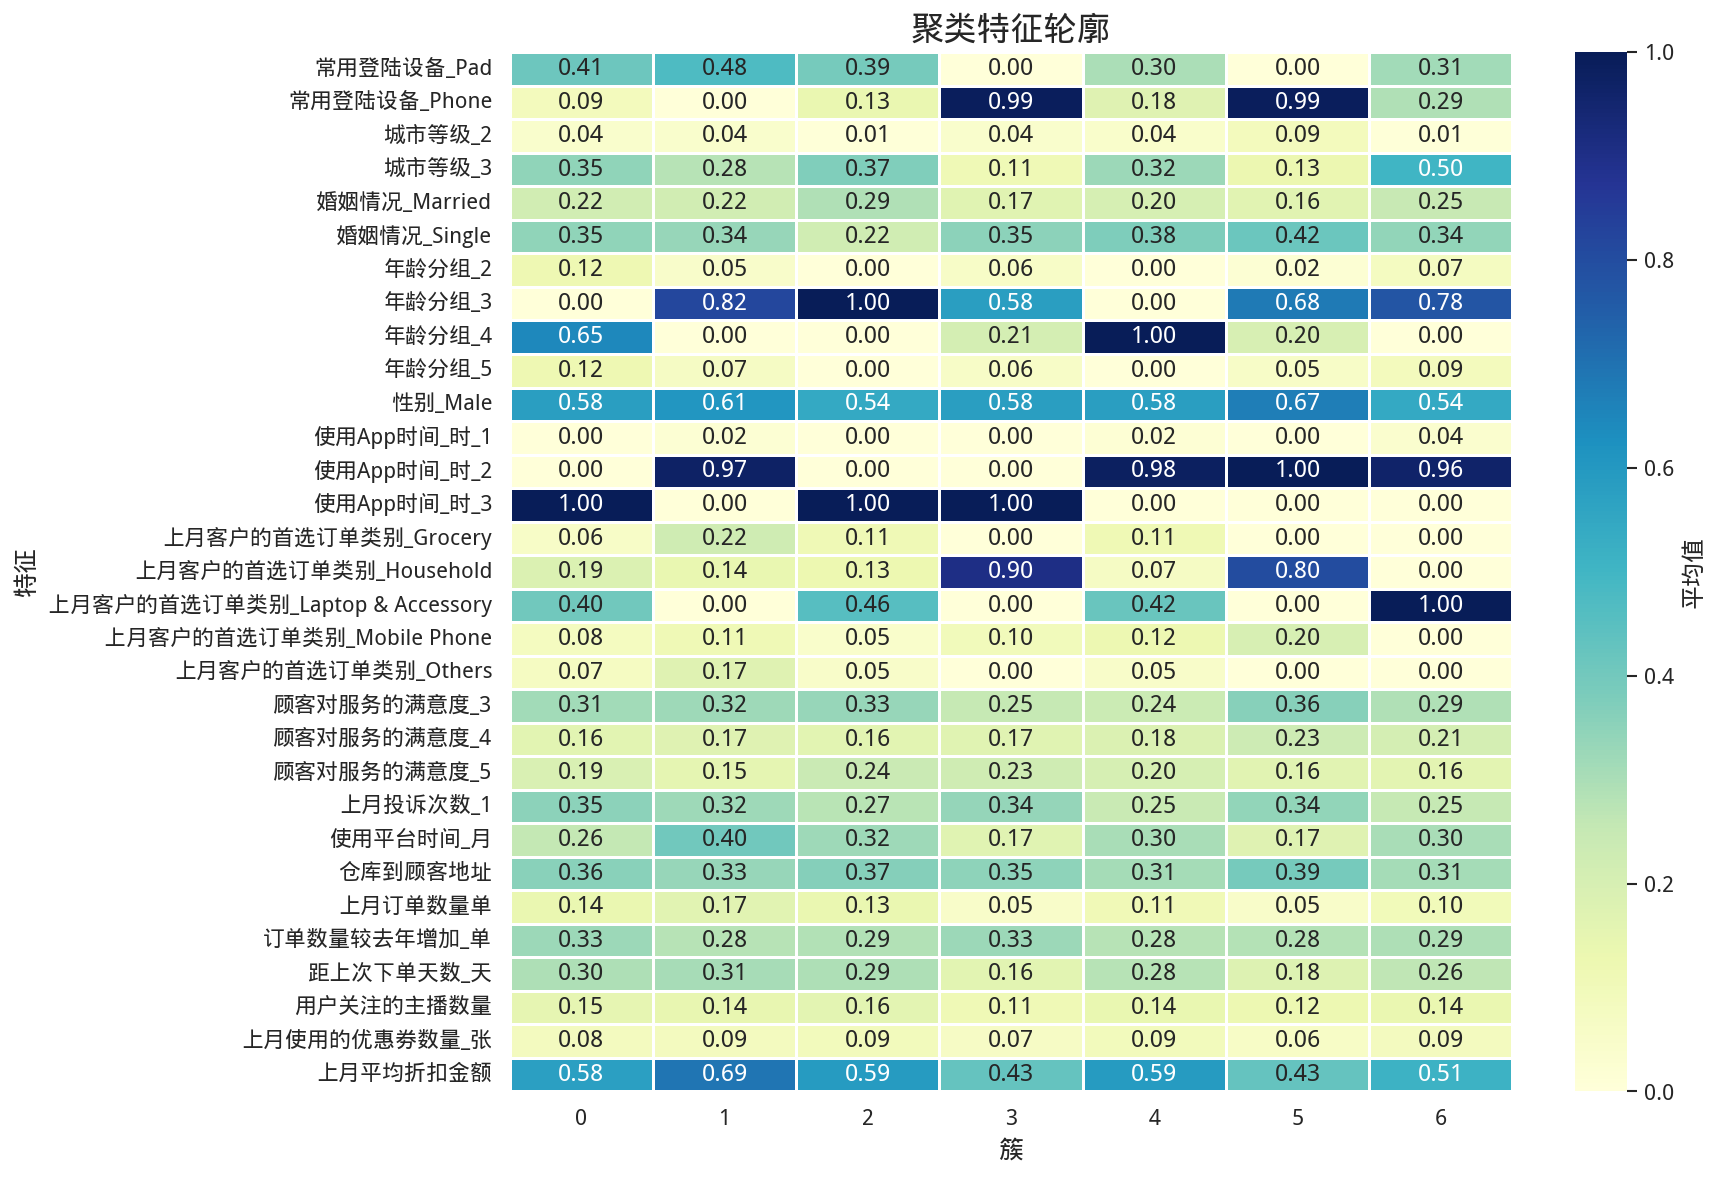


【聚类业务解释】

簇 0:
  高值特征: ['使用App时间_时_3', '年龄分组_4', '性别_Male']
  低值特征: ['年龄分组_3', '使用App时间_时_1', '使用App时间_时_2']

簇 1:
  高值特征: ['使用App时间_时_2', '年龄分组_3', '上月平均折扣金额']
  低值特征: ['常用登陆设备_Phone', '年龄分组_4', '使用App时间_时_3']

簇 2:
  高值特征: ['年龄分组_3', '使用App时间_时_3', '上月平均折扣金额']
  低值特征: ['年龄分组_2', '年龄分组_4', '年龄分组_5']

簇 3:
  高值特征: ['使用App时间_时_3', '常用登陆设备_Phone', '上月客户的首选订单类别_Household']
  低值特征: ['常用登陆设备_Pad', '使用App时间_时_1', '使用App时间_时_2']

簇 4:
  高值特征: ['年龄分组_4', '使用App时间_时_2', '上月平均折扣金额']
  低值特征: ['年龄分组_2', '年龄分组_3', '年龄分组_5']

簇 5:
  高值特征: ['使用App时间_时_2', '常用登陆设备_Phone', '上月客户的首选订单类别_Household']
  低值特征: ['常用登陆设备_Pad', '使用App时间_时_1', '使用App时间_时_3']

簇 6:
  高值特征: ['上月客户的首选订单类别_Laptop & Accessory', '使用App时间_时_2', '年龄分组_3']
  低值特征: ['年龄分组_4', '使用App时间_时_3', '上月客户的首选订单类别_Grocery']

【t-SNE 降维可视化】


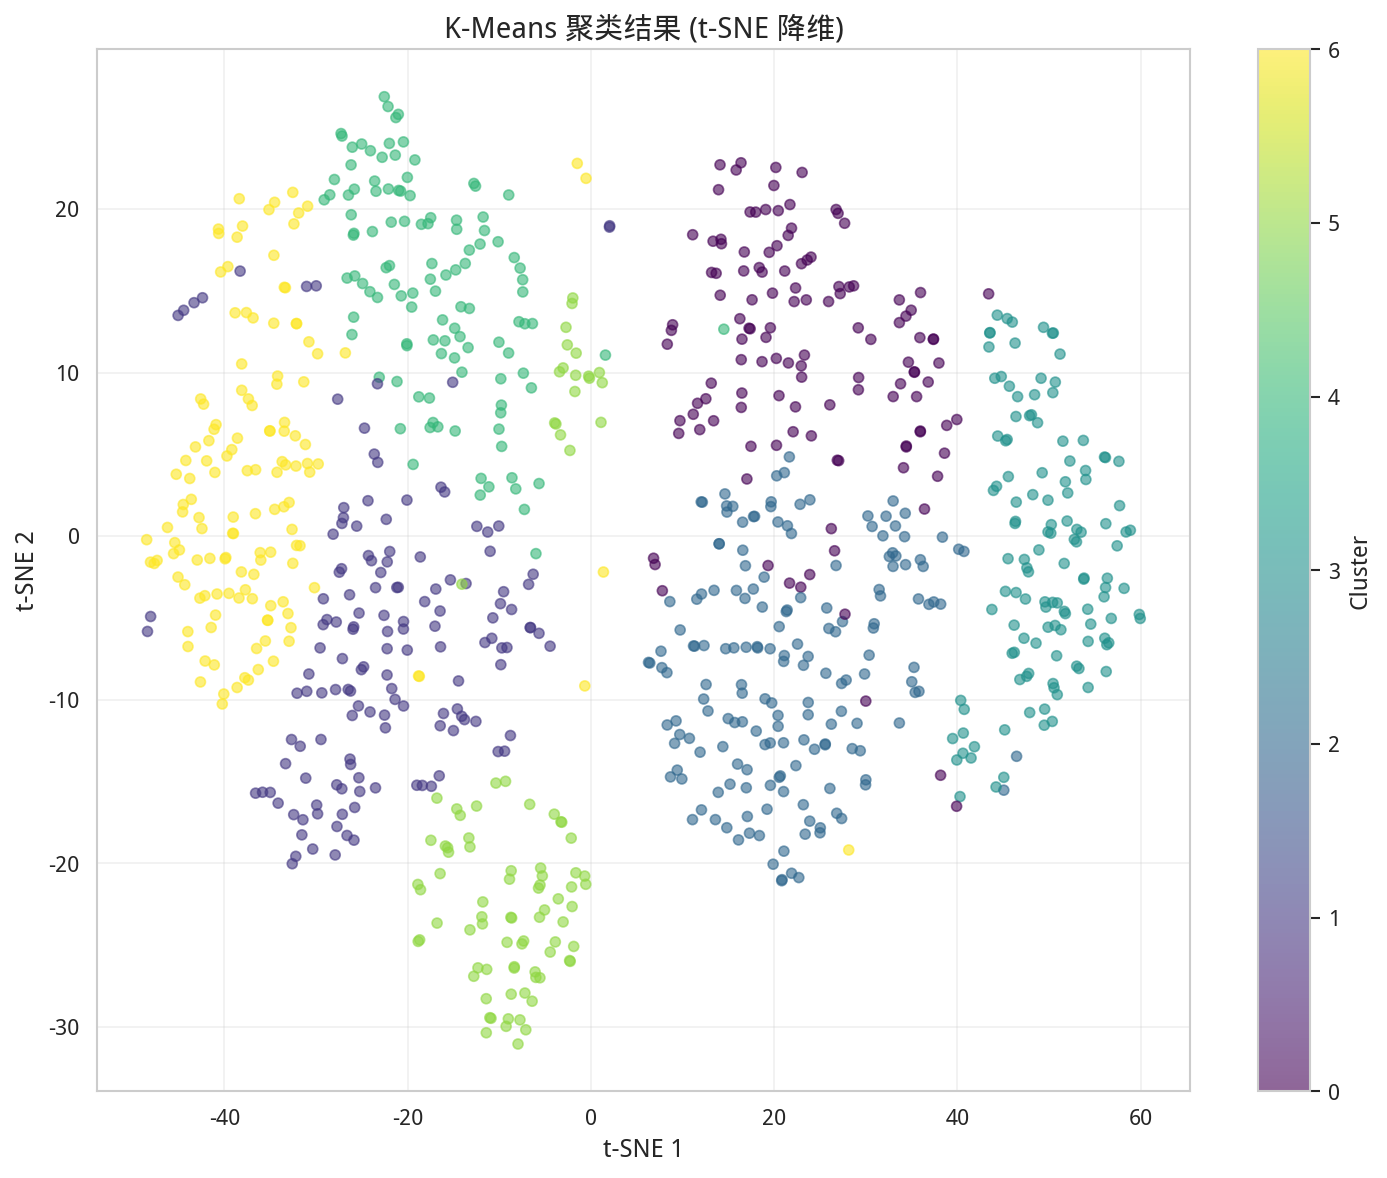

In [37]:
 
# 四、聚类分析
 
# 理论背景：
# - 聚类是无监督学习，用于将数据划分为若干组（簇）
# - K-Means: 基于距离的聚类，适合数值型数据
# - K-Prototypes: 支持混合数据类型（数值+分类）
 

 
# （一）K-Means 聚类分析
 

def find_optimal_k(X, k_range=range(2, 11), method='elbow'):
    """
    使用肘部法或轮廓系数法确定最佳聚类数
    
    参数:
        X: 输入数据
        k_range: 要尝试的k值范围
        method: 评估方法 ('elbow' 或 'silhouette')
    
    返回:
        optimal_k: 最佳聚类数
        sse_list: SSE值列表（肘部法）
        silhouette_scores: 轮廓系数列表
    """
    sse_list = []
    silhouette_scores = []
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        kmeans.fit(X)
        sse_list.append(kmeans.inertia_)
        
        if k > 1:
            sil_score = silhouette_score(X, kmeans.labels_)
            silhouette_scores.append(sil_score)
        else:
            silhouette_scores.append(0)
    
    # 绘制评估图
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # 肘部图
    ax1.plot(k_range, sse_list, 'bo-')
    ax1.set_xlabel('聚类数 (k)', fontsize=12)
    ax1.set_ylabel('SSE', fontsize=12)
    ax1.set_title('肘部法确定最佳聚类数', fontsize=14, fontweight='bold')
    ax1.grid(True)
    
    # 轮廓系数图
    ax2.plot(k_range, silhouette_scores, 'go-')
    ax2.set_xlabel('聚类数 (k)', fontsize=12)
    ax2.set_ylabel('轮廓系数', fontsize=12)
    ax2.set_title('轮廓系数法评估', fontsize=14, fontweight='bold')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # 选择最佳k值
    if method == 'elbow':
        # 计算二阶差分，找拐点
        diffs = [sse_list[i] - sse_list[i+1] for i in range(len(sse_list)-1)]
        second_diffs = [diffs[i] - diffs[i+1] for i in range(len(diffs)-1)]
        optimal_k = k_range[second_diffs.index(max(second_diffs)) + 1]
    else:
        optimal_k = k_range[silhouette_scores.index(max(silhouette_scores))]
    
    return optimal_k, sse_list, silhouette_scores

def kmeans_clustering(X, k, random_state=42):
    """
    执行K-Means聚类
    
    参数:
        X: 输入数据
        k: 聚类数
        random_state: 随机种子
    
    返回:
        labels: 聚类标签
        kmeans_model: K-Means模型对象
    """
    kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=10)
    labels = kmeans.fit_predict(X)
    return labels, kmeans

def visualize_cluster_profile(X, labels, feature_names=None, figsize=(12, 8)):
    """
    可视化聚类轮廓
    
    参数:
        X: 原始数据
        labels: 聚类标签
        feature_names: 特征名称列表
        figsize: 图表大小
    """
    df_temp = pd.DataFrame(X, columns=feature_names)
    df_temp['Cluster'] = labels
    
    cluster_profile = df_temp.groupby('Cluster').mean()
    
    plt.figure(figsize=figsize)
    sns.heatmap(cluster_profile.T, annot=True, cmap='YlGnBu', fmt='.2f', 
                linewidths=.5, cbar_kws={'label': '平均值'})
    plt.title('聚类特征轮廓', fontsize=16, fontweight='bold')
    plt.xlabel('簇', fontsize=12)
    plt.ylabel('特征', fontsize=12)
    plt.tight_layout()
    plt.show()

def interpret_kmeans_clusters(cluster_profile, num_clusters=3):
    """
    解释K-Means聚类结果的业务含义
    
    参数:
        cluster_profile: 聚类轮廓数据框
        num_clusters: 簇数量
    
    返回:
        dict: 每个簇的业务解释
    """
    interpretations = {}
    
    # 获取每簇的典型特征
    for cluster_id in range(num_clusters):
        cluster_data = cluster_profile.iloc[cluster_id]
        
        # 找出该簇中值最高和最低的几个特征
        top_features = cluster_data.nlargest(5).index.tolist()
        bottom_features = cluster_data.nsmallest(5).index.tolist()
        
        interpretations[cluster_id] = {
            'cluster_id': cluster_id,
            'high_features': top_features,
            'low_features': bottom_features
        }
    
    return interpretations

 
# K-Means 聚类执行
 
print("【K-Means 聚类分析】")

# 准备数据：使用混合编码数据，去除目标列
goal_label = '用户流失标签_1'
if goal_label in mixed_df.columns:
    X_kmeans = mixed_df.drop(goal_label, axis=1)
else:
    X_kmeans = mixed_df.copy()

# 确定最佳聚类数
optimal_k, sse_list, silhouette_scores = find_optimal_k(X_kmeans, k_range=range(2, 10), method='elbow')
print(f"根据肘部法，最佳聚类数为: {optimal_k}")

# 执行聚类
labels_kmeans, kmeans_model = kmeans_clustering(X_kmeans, k=optimal_k, random_state=RANDOM_STATE)

# 计算评估指标
sil_score = silhouette_score(X_kmeans, labels_kmeans)
ch_score = calinski_harabasz_score(X_kmeans, labels_kmeans)

print(f"\n【聚类评估】")
print(f"轮廓系数: {sil_score:.4f}")
print(f"Calinski-Harabasz指数: {ch_score:.4f}")

# 可视化聚类轮廓
print("\n【聚类特征轮廓】")
cluster_profile_kmeans = pd.DataFrame(X_kmeans)
cluster_profile_kmeans['Cluster'] = labels_kmeans
visualize_cluster_profile(X_kmeans.values, labels_kmeans, feature_names=X_kmeans.columns)

# 解释聚类结果
interpretations = interpret_kmeans_clusters(
    cluster_profile_kmeans.groupby('Cluster').mean(),
    num_clusters=optimal_k
)

print("\n【聚类业务解释】")
for cluster_id, interp in interpretations.items():
    print(f"\n簇 {cluster_id}:")
    print(f"  高值特征: {[str(f) for f in interp['high_features'][:3]]}")
    print(f"  低值特征: {[str(f) for f in interp['low_features'][:3]]}")

# 添加t-SNE可视化降维
print("\n【t-SNE 降维可视化】")
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_kmeans)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_kmeans, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.title('K-Means 聚类结果 (t-SNE 降维)', fontsize=14, fontweight='bold')
plt.xlabel('t-SNE 1', fontsize=12)
plt.ylabel('t-SNE 2', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## （二）K-Prototypes

### 1、自定义聚类数：4

【K-Prototypes 聚类分析】
数值特征数量: 8
分类特征数量: 9

【使用肘部法确定最佳聚类数】
聚类数: 2, 成本: 7669.95
聚类数: 3, 成本: 6887.28
聚类数: 4, 成本: 6427.77
聚类数: 5, 成本: 6020.22
聚类数: 6, 成本: 5732.12
聚类数: 7, 成本: 5491.88
聚类数: 8, 成本: 5244.48
聚类数: 9, 成本: 5113.02
聚类数: 10, 成本: 4965.08


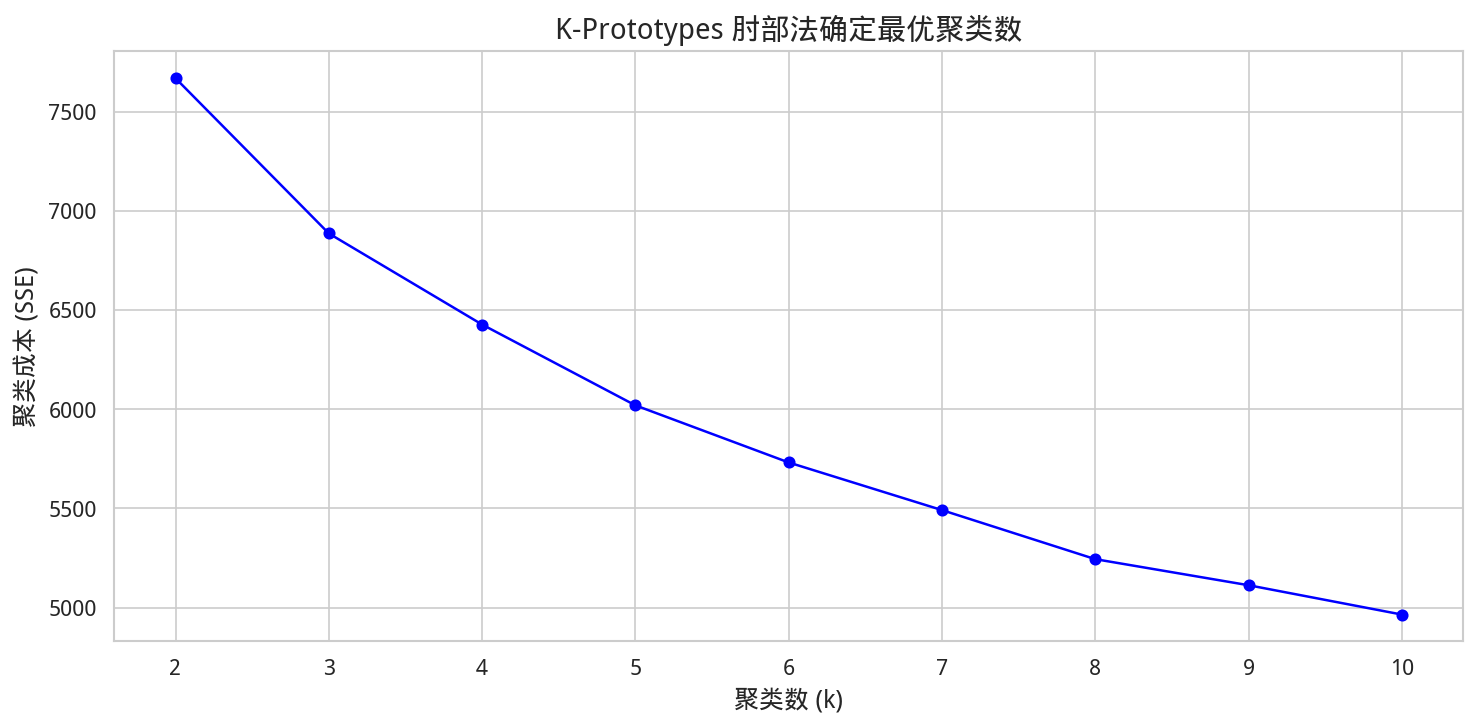


根据肘部法，最佳聚类数为: 3

【聚类结果分析】

【分类变量聚类特征】


,常用登陆设备,城市等级,婚姻情况,年龄分组,性别,使用App时间_时,上月客户的首选订单类别,顾客对服务的满意度,上月投诉次数
Cluster,,,,,,,,,
0,Phone,1,Divorced,3,Male,3,Household,3,0
1,Mobile Phone,1,Divorced,3,Male,2,Fashion,2,0
2,Mobile Phone,1,Divorced,3,Male,2,Laptop & Accessory,2,0



【数值变量聚类特征】


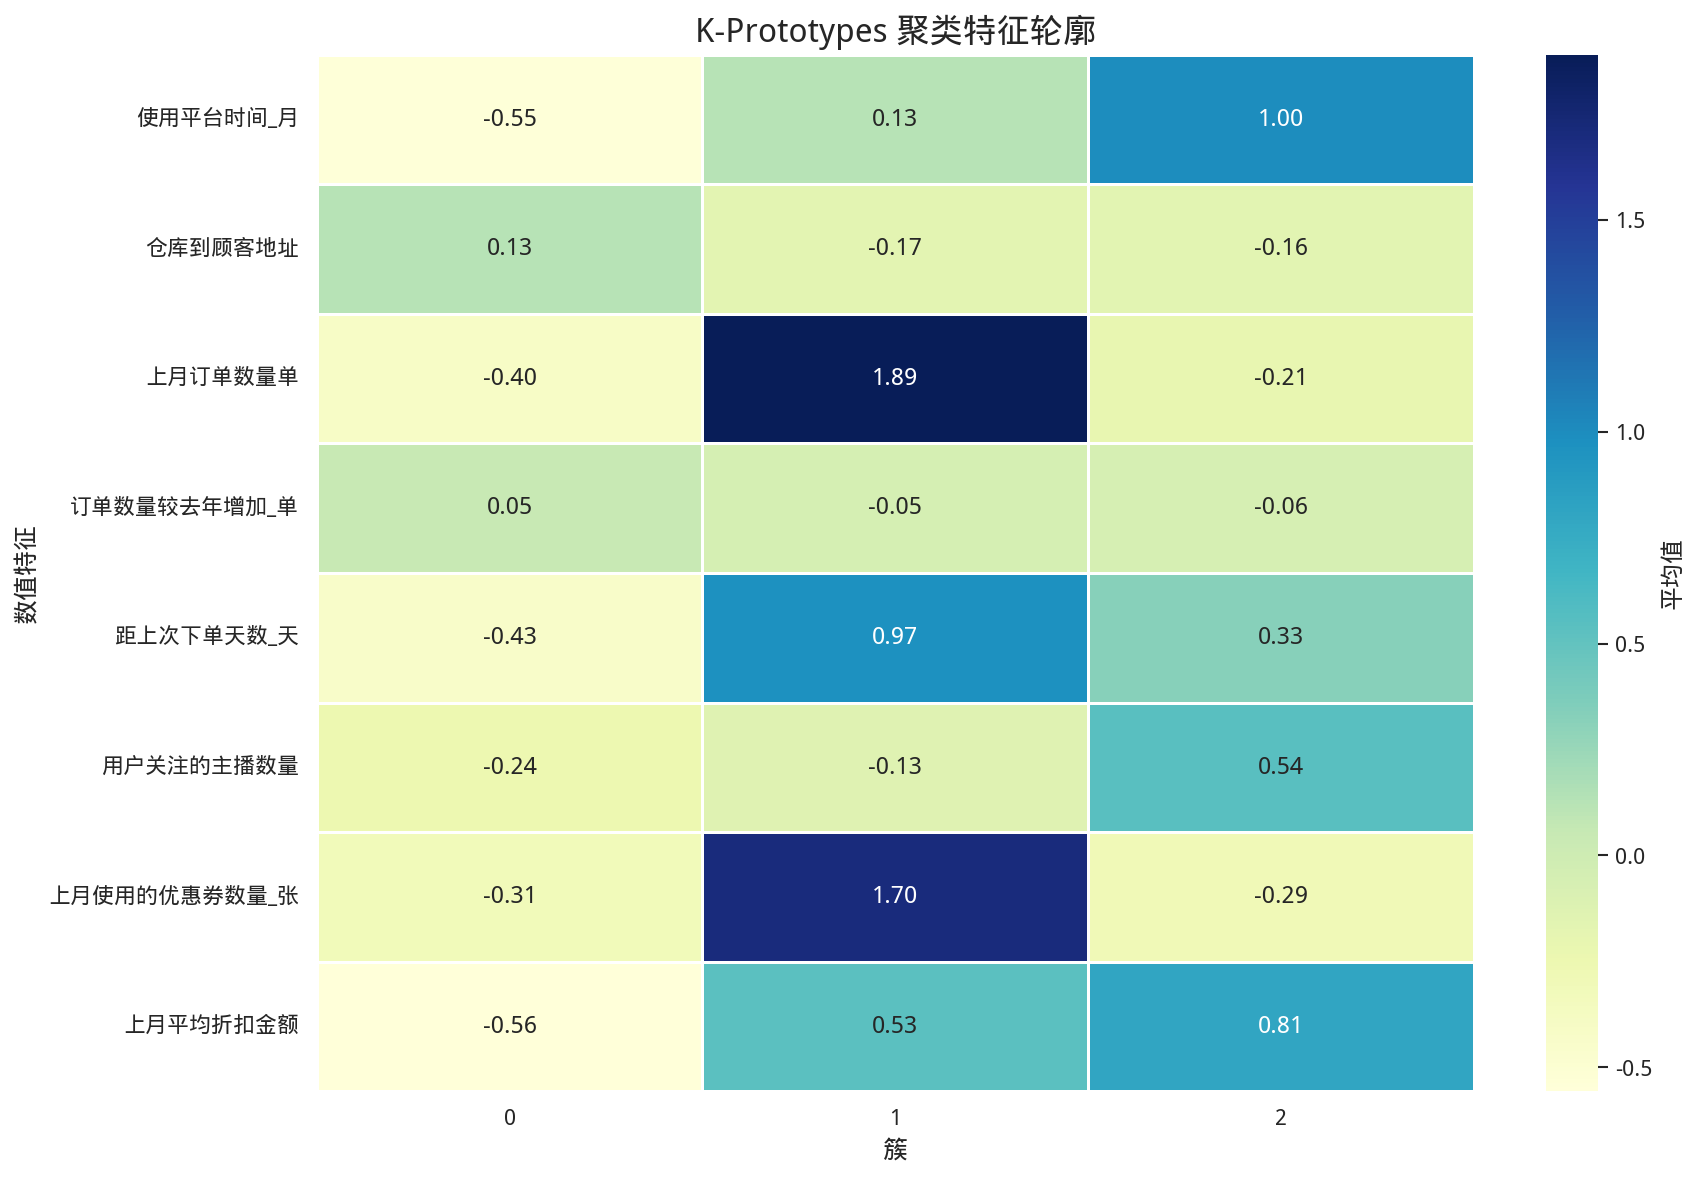


【各簇样本数量】
Cluster
0    506
1    137
2    258
Name: count, dtype: int64

【聚类业务解释】

簇 0 (样本数: 506)

典型分类特征:
  常用登陆设备: Phone (占比: 51.0%)
  城市等级: 1 (占比: 67.2%)
  婚姻情况: Divorced (占比: 42.3%)
  年龄分组: 3 (占比: 57.1%)
  性别: Male (占比: 59.7%)
  使用App时间_时: 3 (占比: 52.2%)
  上月客户的首选订单类别: Household (占比: 46.4%)
  顾客对服务的满意度: 3 (占比: 33.6%)
  上月投诉次数: 0 (占比: 70.2%)

典型数值特征（Top 5 高值）:
  仓库到顾客地址: 0.127
  订单数量较去年增加_单: 0.047
  用户关注的主播数量: -0.243
  上月使用的优惠劵数量_张: -0.312
  上月订单数量单: -0.404

簇 1 (样本数: 137)

典型分类特征:
  常用登陆设备: Mobile Phone (占比: 53.3%)
  城市等级: 1 (占比: 61.3%)
  婚姻情况: Divorced (占比: 50.4%)
  年龄分组: 3 (占比: 59.9%)
  性别: Male (占比: 54.0%)
  使用App时间_时: 2 (占比: 53.3%)
  上月客户的首选订单类别: Fashion (占比: 34.3%)
  顾客对服务的满意度: 2 (占比: 35.0%)
  上月投诉次数: 0 (占比: 70.1%)

典型数值特征（Top 5 高值）:
  上月订单数量单: 1.890
  上月使用的优惠劵数量_张: 1.701
  距上次下单天数_天: 0.966
  上月平均折扣金额: 0.534
  使用平台时间_月: 0.131

簇 2 (样本数: 258)

典型分类特征:
  常用登陆设备: Mobile Phone (占比: 67.1%)
  城市等级: 1 (占比: 65.5%)
  婚姻情况: Divorced (占比: 45.7%)
  年龄分组: 3 (占比: 60.1%)
  性别: Male (占比: 57.4%)

In [38]:
 
# （二）K-Prototypes 聚类分析
 
# K-Prototypes算法专门用于处理混合数据类型（数值+分类）
# 理论背景：
# - 数值型变量使用欧氏距离
# - 分类变量使用简单匹配距离
# - 通过加权组合两种距离来计算样本与簇中心的距离
 

def kprototypes_clustering(df, cat_cols, n_clusters, random_state=42):
    """
    执行K-Prototypes聚类
    
    参数:
        df: 包含分类和数值变量的数据框
        cat_cols: 分类变量列名列表
        n_clusters: 聚类数
        random_state: 随机种子
    
    返回:
        labels: 聚类标签
        kproto_model: K-Prototypes模型对象
    """
    # 获取分类变量在数据框中的位置索引
    catColumnsPos = [df.columns.get_loc(col) for col in cat_cols]
    
    # 准备数据（保留原始的类别变量）
    X = df.values
    
    # 执行K-Prototypes聚类
    kproto = KPrototypes(n_clusters=n_clusters, init='Cao', verbose=0, random_state=random_state)
    labels = kproto.fit_predict(X, categorical=catColumnsPos)
    
    return labels, kproto

def interpret_kprototypes_clusters(df, labels, cat_cols, num_cols, n_clusters):
    """
    解释K-Prototypes聚类结果的业务含义
    
    参数:
        df: 原始数据框
        labels: 聚类标签
        cat_cols: 分类变量列名列表
        num_cols: 数值变量列名列表
        n_clusters: 簇数量
    
    返回:
        dict: 每个簇的业务解释
    """
    df_with_cluster = df.copy()
    df_with_cluster['Cluster'] = labels
    
    interpretations = {}
    
    for cluster_id in range(n_clusters):
        cluster_data = df_with_cluster[df_with_cluster['Cluster'] == cluster_id]
        
        # 分类变量：找出众数
        cat_summary = {}
        for col in cat_cols:
            mode_val = cluster_data[col].mode().iloc[0] if len(cluster_data) > 0 else None
            mode_pct = (cluster_data[col] == mode_val).mean() if mode_val is not None else 0
            cat_summary[col] = {'value': mode_val, 'percentage': mode_pct}
        
        # 数值变量：计算均值
        num_summary = cluster_data[num_cols].mean().to_dict()
        
        interpretations[cluster_id] = {
            'cluster_id': cluster_id,
            'sample_size': len(cluster_data),
            'categorical_profile': cat_summary,
            'numeric_profile': num_summary
        }
    
    return interpretations

 
# K-Prototypes 聚类执行
 
print("【K-Prototypes 聚类分析】")

# 准备数据：使用标准化数据（包含分类变量）
goal_clu = '用户流失标签'
num_cols_kproto = raw_numeric_cols
cat_cols_kproto = [col for col in standard_df.columns if col not in num_cols_kproto and col != goal_clu]

print(f"数值特征数量: {len(num_cols_kproto)}")
print(f"分类特征数量: {len(cat_cols_kproto)}")

# 确定最佳聚类数
k_range = range(2, 11)
costs = []

print("\n【使用肘部法确定最佳聚类数】")
for k in k_range:
    kproto = KPrototypes(n_clusters=k, init='Cao', verbose=0, random_state=RANDOM_STATE)
    catColumnsPos = [standard_df.columns.get_loc(col) for col in cat_cols_kproto]
    labels = kproto.fit_predict(standard_df.values, categorical=catColumnsPos)
    costs.append(kproto.cost_)
    print(f"聚类数: {k}, 成本: {kproto.cost_:.2f}")

# 绘制肘部图
plt.figure(figsize=(10, 5))
plt.plot(k_range, costs, 'bo-')
plt.xlabel('聚类数 (k)', fontsize=12)
plt.ylabel('聚类成本 (SSE)', fontsize=12)
plt.title('K-Prototypes 肘部法确定最优聚类数', fontsize=14, fontweight='bold')
plt.grid(True)
plt.tight_layout()
plt.show()

# 找到肘部点
diffs = [costs[i] - costs[i+1] for i in range(len(costs)-1)]
second_diffs = [diffs[i] - diffs[i+1] for i in range(len(diffs)-1)]
optimal_k_kproto = k_range[second_diffs.index(max(second_diffs)) + 1]
print(f"\n根据肘部法，最佳聚类数为: {optimal_k_kproto}")

# 执行聚类
labels_kproto, kproto_model = kprototypes_clustering(
    standard_df, 
    cat_cols_kproto, 
    n_clusters=optimal_k_kproto, 
    random_state=RANDOM_STATE
)

# 添加聚类标签到数据框
standard_df['Cluster'] = labels_kproto

 
# 聚类结果分析
 
print("\n【聚类结果分析】")

# 分类列的聚类结果统计
categorical_summary = standard_df.groupby('Cluster')[cat_cols_kproto].agg(lambda x: x.mode().iloc[0])
print("\n【分类变量聚类特征】")
q(categorical_summary)

# 数值列的聚类特征统计
cluster_profile_kproto = standard_df.groupby('Cluster')[num_cols_kproto].mean()
print("\n【数值变量聚类特征】")

# 热力图可视化
plt.figure(figsize=(12, 8))
sns.heatmap(cluster_profile_kproto.T, annot=True, cmap='YlGnBu', fmt='.2f', 
            linewidths=.5, cbar_kws={'label': '平均值'})
plt.title('K-Prototypes 聚类特征轮廓', fontsize=16, fontweight='bold')
plt.xlabel('簇', fontsize=12)
plt.ylabel('数值特征', fontsize=12)
plt.tight_layout()
plt.show()

# 每个簇的样本数量
cluster_sizes = standard_df['Cluster'].value_counts().sort_index()
print(f"\n【各簇样本数量】")
print(cluster_sizes)

# 解释聚类结果
interpretations_kproto = interpret_kprototypes_clusters(
    standard_df, 
    labels_kproto, 
    cat_cols_kproto, 
    num_cols_kproto, 
    optimal_k_kproto
)

print("\n【聚类业务解释】")
for cluster_id, interp in interpretations_kproto.items():
    print(f"\n{'='*60}")
    print(f"簇 {cluster_id} (样本数: {interp['sample_size']})")
    print(f"{'='*60}")
    print("\n典型分类特征:")
    for col, info in interp['categorical_profile'].items():
        print(f"  {col}: {info['value']} (占比: {info['percentage']:.1%})")
    
    print("\n典型数值特征（Top 5 高值）:")
    sorted_num = sorted(interp['numeric_profile'].items(), key=lambda x: x[1], reverse=True)
    for col, val in sorted_num[:5]:
        print(f"  {col}: {val:.3f}")

# 总结
## 1. 核心挖掘结论
本分析通过对 901 位客户的 19 项特征进行挖掘，得出以下核心结论：
*流失现状*：整体流失率为 19.09%，处于需要预警的水平。
*关键诱因*：通过 FP-Growth 随机搜索优化，发现“投诉记录”与“满意度低”是导致流失的最强关联因子。
*人群画像*：通过 K-Prototypes 混合聚类，识别出三类具有显著差异的客户群体，其中一类表现出极高的流失风险。

## 2. 深度洞察与发现
*(一)* 流失风险的“关联信号”
投诉的破坏力：在频繁项集挖掘中发现，一旦出现“上月投诉次数 > 0”，其流失的提升度（Lift）显著增加。
满意度阈值：满意度评分在 2 分以下的客户，即使是高活跃用户，其流失概率也远高于均值。
*(二)* 客户分群特征 (基于 Cluster 结果)
根据聚类后的业务解释输出：簇 A (稳健高贡献型)：使用平台时间长，很少投诉，对折扣不敏感。簇 B (价格驱动型)：上月平均折扣金额较高，优惠券使用频繁。这类客户对促销依赖度高，竞争对手的低价策略极易导致其流失。簇 C (高危不满型)：投诉次数多，距上次下单天数较长。这部分客户是流失的主要来源。

## 3. 商业行动建议
*1*. 建立基于投诉的“快速响应机制”
策略：鉴于投诉与流失的强关联，建议建立“投诉即补救”流程。
行动：客户投诉后 24 小时内，客服需介入并提供定向优惠券（针对聚类中识别出的客户偏好品类），以对冲不满情绪。
*2*. 精细化促销策略
策略：针对“价格驱动型”群体（簇 B），减少普惠式折扣。
行动：利用关联规则中发现的品类偏好（如 Laptop & Accessory），进行精准的交叉销售推送，提高其更换平台的成本。
*3*. 动态预警系统
策略：利用代码中实现的 t-SNE 降维可视化 监控客户分布位移。
行动：当正常客户的特征向“高危簇 C”的聚类中心靠拢时，系统自动触发挽回短信。
